# Viken KHATCHERIAN projet 10 Openclassrooms 

# 0. BrainScanAI — Extraction de caractéristiques et clustering d'images cérébrales

## Contexte

Ce notebook s'inscrit dans le cadre du projet OpenClassrooms :

**« Labellisez et appliquez des approches semi-supervisées en traitement d'images »**

L'objectif est d'étudier la faisabilité d'une approche de Computer Vision permettant
d'exploiter un jeu d'images cérébrales comprenant une quantité limitée de données
étiquetées et un volume plus important de données non étiquetées.

## Objectifs du notebook

Ce premier notebook est consacré à :

1. l'exploration et au contrôle qualité des données ;
2. la préparation des images pour un modèle de Computer Vision pré-entraîné ;
3. l'extraction de représentations visuelles (*embeddings*) ;
4. l'exploration de la structure des données dans l'espace des représentations ;
5. l'application et la comparaison de plusieurs méthodes de clustering.

Les résultats obtenus ici serviront de base au **Notebook 2**, consacré à
l'approche semi-supervisée et à l'exploitation des données non étiquetées.

## Données

Le dataset fourni contient :

- 1 400 images non étiquetées ;
- 100 images étiquetées ;
- 50 images de la classe `cancer` ;
- 50 images de la classe `normal` ;
- des images au format JPEG (`.jpg`) ;
- une résolution annoncée de 512 × 512 pixels.

Une vérification du contenu réellement fourni sera effectuée dans ce notebook
avant tout traitement.

## Périmètre et limites

Cette étude constitue une **étude exploratoire de faisabilité en Computer Vision**.
Elle ne constitue pas un dispositif médical ni un système de diagnostic clinique.

Une attention particulière sera portée à la qualité des données, aux biais
potentiels, aux erreurs de classification et à la reproductibilité des traitements.

# Etape 1 - Importer les données et explorez le jeu de radiographies

# 1. Importation et exploration des données 

In [1]:
# Importation des bibliothèques


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision

import sklearn
import cv2

In [2]:
# Vérification des versions des principales bibliothèques

print(f"Python       : {__import__('sys').version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Matplotlib   : {__import__('matplotlib').__version__}")
print(f"Pillow       : {__import__('PIL').__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Torchvision  : {torchvision.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"OpenCV       : {cv2.__version__}")

Python       : 3.11.14
NumPy        : 2.3.3
Pandas       : 3.0.5
Matplotlib   : 3.10.8
Pillow       : 11.3.0
PyTorch      : 2.9.1+cu128
Torchvision  : 0.24.1+cu128
Scikit-learn : 1.9.0
OpenCV       : 5.0.0


## Chargement et exploration de la structure du dataset

Le dataset est organisé en trois catégories :

- `avec_labels/cancer` : images étiquetées comme présentant des signes de tumeur ;
- `avec_labels/normal` : images étiquetées comme normales ;
- `sans_label` : images ne disposant pas d'étiquette.

Dans un premier temps, nous vérifions automatiquement la structure et le nombre
de fichiers présents dans chaque répertoire avant d'effectuer l'exploration
visuelle et le contrôle qualité des images.

In [3]:
# Chargement et exploration de la structure du dataset


from pathlib import Path

# Répertoire racine du dataset extrait
DATASET_DIR = (
    Path.cwd().parent
    / "data"
    / "raw"
    / "dataset_original"
    / "dataset_extracted"
    / "mri_dataset_brain_cancer_oc"
)

# Vérification de l'existence du dataset
print(f"Répertoire du dataset : {DATASET_DIR}")
print(f"Répertoire trouvé : {DATASET_DIR.exists()}")

# Définition des sous-répertoires
CANCER_DIR = DATASET_DIR / "avec_labels" / "cancer"
NORMAL_DIR = DATASET_DIR / "avec_labels" / "normal"
UNLABELED_DIR = DATASET_DIR / "sans_label"

print("\nStructure attendue :")
for name, path in {
    "Cancer": CANCER_DIR,
    "Normal": NORMAL_DIR,
    "Sans label": UNLABELED_DIR,
}.items():
    print(f"- {name:10} : {path.exists()} → {path}")

Répertoire du dataset : /mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc
Répertoire trouvé : True

Structure attendue :
- Cancer     : True → /mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/cancer
- Normal     : True → /mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/normal
- Sans label : True → /mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/sans_label


## Inventaire des images

Nous comptons les fichiers JPEG présents dans chaque sous-ensemble afin de
vérifier la cohérence entre la documentation fournie avec le dataset et les
données effectivement extraites.

Cette vérification permet également d'identifier un éventuel déséquilibre entre
les classes étiquetées et de documenter les éventuelles anomalies avant tout
prétraitement.

In [4]:
# Comptage des images JPEG dans chaque sous-ensemble

def count_jpg_images(directory):
    """Compte les fichiers JPG présents directement dans un répertoire."""
    return len(list(directory.glob("*.jpg")))


n_cancer = count_jpg_images(CANCER_DIR)
n_normal = count_jpg_images(NORMAL_DIR)
n_unlabeled = count_jpg_images(UNLABELED_DIR)

n_labeled = n_cancer + n_normal
n_total = n_labeled + n_unlabeled

inventory = pd.DataFrame(
    {
        "Sous-ensemble": ["Cancer", "Normal", "Sans label", "Total"],
        "Nombre d'images": [
            n_cancer,
            n_normal,
            n_unlabeled,
            n_total,
        ],
    }
)

inventory

,Sous-ensemble,Nombre d'images
0,Cancer,50
1,Normal,50
2,Sans label,1406
3,Total,1506


## Contrôle technique des images

Avant toute transformation, nous vérifions les caractéristiques réelles des images :
résolution, mode couleur, format et capacité de lecture.

Le contrôle est effectué sur l'ensemble des images disponibles afin d'identifier
d'éventuelles incohérences ou fichiers problématiques avant le preprocessing.

In [5]:
# Contrôle technique des images


def collect_image_metadata(directory, subset, label):
    """
    Parcourt les images JPG d'un répertoire et collecte leurs
    principales caractéristiques techniques.
    """
    
    records = []
    
    for image_path in sorted(directory.glob("*.jpg")):
        record = {
            "path": str(image_path),
            "subset": subset,
            "label": label,
            "filename": image_path.name,
            "format": None,
            "width": None,
            "height": None,
            "mode": None,
            "file_size_kb": round(image_path.stat().st_size / 1024, 2),
            "readable": False,
        }
        
        try:
            with Image.open(image_path) as img:
                record["format"] = img.format
                record["width"] = img.width
                record["height"] = img.height
                record["mode"] = img.mode
                record["readable"] = True
                
        except Exception as e:
            record["error"] = str(e)
        
        records.append(record)
    
    return records


# Collecte des métadonnées des trois sous-ensembles
metadata_records = []

metadata_records.extend(
    collect_image_metadata(CANCER_DIR, "avec_labels", "cancer")
)

metadata_records.extend(
    collect_image_metadata(NORMAL_DIR, "avec_labels", "normal")
)

metadata_records.extend(
    collect_image_metadata(UNLABELED_DIR, "sans_label", None)
)

images_metadata = pd.DataFrame(metadata_records)

print(f"Nombre d'images inspectées : {len(images_metadata)}")
print(f"Images lisibles            : {images_metadata['readable'].sum()}")
print(f"Images non lisibles        : {(~images_metadata['readable']).sum()}")

Nombre d'images inspectées : 1506
Images lisibles            : 1506
Images non lisibles        : 0


In [6]:
# Vérification de la résolution des images


resolution_counts = (
    images_metadata[images_metadata["readable"]]
    .groupby(["width", "height"])
    .size()
    .reset_index(name="nombre_images")
    .sort_values("nombre_images", ascending=False)
)

resolution_counts

,width,height,nombre_images
0,512,512,1506


In [7]:
# Vérification de la résolution annoncée par la documentation

expected_resolution = (512, 512)

n_expected_resolution = (
    (images_metadata["width"] == expected_resolution[0]) &
    (images_metadata["height"] == expected_resolution[1])
).sum()

n_other_resolution = len(images_metadata) - n_expected_resolution

print(f"Résolution attendue : {expected_resolution[0]} × {expected_resolution[1]}")
print(f"Images en 512 × 512 : {n_expected_resolution}")
print(f"Autres résolutions  : {n_other_resolution}")

Résolution attendue : 512 × 512
Images en 512 × 512 : 1506
Autres résolutions  : 0


In [8]:
# Vérification des modes couleur


mode_counts = (
    images_metadata[images_metadata["readable"]]["mode"]
    .value_counts()
    .rename_axis("mode")
    .reset_index(name="nombre_images")
)

mode_counts

,mode,nombre_images
0,RGB,1506


In [9]:
# Vérification des formats de fichiers

format_counts = (
    images_metadata[images_metadata["readable"]]["format"]
    .value_counts()
    .rename_axis("format")
    .reset_index(name="nombre_images")
)

format_counts

,format,nombre_images
0,JPEG,1506


In [10]:
# Contrôle de qualité des fichiers


unreadable_images = images_metadata[
    ~images_metadata["readable"]
]

if len(unreadable_images) == 0:
    print("Aucune image illisible détectée.")
else:
    print(f"{len(unreadable_images)} image(s) illisible(s) détectée(s).")
    display(unreadable_images)

Aucune image illisible détectée.


In [11]:
# Analyse de l'écart entre la documentation et les fichiers réels


expected_total = 1500
expected_labeled = 100
expected_unlabeled = 1400

actual_cancer = len(list(CANCER_DIR.glob("*.jpg")))
actual_normal = len(list(NORMAL_DIR.glob("*.jpg")))
actual_unlabeled = len(list(UNLABELED_DIR.glob("*.jpg")))

actual_labeled = actual_cancer + actual_normal
actual_total = actual_labeled + actual_unlabeled

print("Comparaison documentation / données réelles")
print("=" * 55)

print(f"Images labellisées attendues : {expected_labeled}")
print(f"Images labellisées réelles   : {actual_labeled}")
print(f"Écart labellisé              : {actual_labeled - expected_labeled}")

print()

print(f"Images sans label attendues  : {expected_unlabeled}")
print(f"Images sans label réelles    : {actual_unlabeled}")
print(f"Écart sans label             : {actual_unlabeled - expected_unlabeled}")

print()

print(f"Images totales attendues     : {expected_total}")
print(f"Images totales réelles       : {actual_total}")
print(f"Écart total                  : {actual_total - expected_total}")

Comparaison documentation / données réelles
Images labellisées attendues : 100
Images labellisées réelles   : 100
Écart labellisé              : 0

Images sans label attendues  : 1400
Images sans label réelles    : 1406
Écart sans label             : 6

Images totales attendues     : 1500
Images totales réelles       : 1506
Écart total                  : 6


« La documentation annonce 1 500 images, dont 1 400 non étiquetées. L'exploration effective du jeu de données extrait révèle 1 506 images JPEG : 50 images cancer, 50 images normal et 1 406 images sans_label. L'écart de 6 images concerne exclusivement le sous-ensemble non étiqueté. Aucune image n'étant illisible et toutes respectant le format 512×512 RGB JPEG, les 6 images supplémentaires sont conservées afin de ne pas supprimer arbitrairement des données. »

In [12]:
# Inventaire des images par sous-ensemble


from collections import Counter

all_images = []

for label, directory in {
    "cancer": CANCER_DIR,
    "normal": NORMAL_DIR,
    "sans_label": UNLABELED_DIR,
}.items():
    for image_path in directory.glob("*.jpg"):
        all_images.append({
            "label": label,
            "filename": image_path.name,
            "path": str(image_path),
        })

images_df = pd.DataFrame(all_images)

print(f"Nombre total d'images : {len(images_df)}")
print()
print(images_df["label"].value_counts())

Nombre total d'images : 1506

label
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64


In [13]:
# Recherche de doublons exacts par empreinte MD5


import hashlib

def md5_file(path):
    hash_md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

images_df["md5"] = images_df["path"].apply(md5_file)

duplicate_groups = (
    images_df.groupby("md5")
    .filter(lambda group: len(group) > 1)
    .sort_values("md5")
)

print(f"Nombre d'images : {len(images_df)}")
print(f"Nombre de groupes de doublons exacts : "
      f"{duplicate_groups['md5'].nunique()}")

if len(duplicate_groups) == 0:
    print("Aucun doublon exact détecté.")
else:
    print("\nDoublons détectés :")
    display(duplicate_groups[["label", "filename", "md5"]])

Nombre d'images : 1506
Nombre de groupes de doublons exacts : 90

Doublons détectés :


,label,filename,md5
1098,sans_label,a74cd797-2401-44e9-b29b-e3e125c8e148.jpg,038bd3a36c6463f3a9f18ac031ea1c4d
1291,sans_label,63f74ae7-15f3-40e6-90f8-850dd20dbb70.jpg,038bd3a36c6463f3a9f18ac031ea1c4d
76,normal,defdbef3-bea2-4f32-9d9a-62af1102ebfd.jpg,0652cb55477c4edeea5c5dfd53944e3b
1049,sans_label,b65c7ebe-aac9-414e-a9d3-b8205d5d5a23.jpg,0652cb55477c4edeea5c5dfd53944e3b
87,normal,9e761fb7-da77-4feb-b268-2d873293ee78.jpg,0816537db58c1d8092808f2c6f75e96c
...,...,...,...
1260,sans_label,e1f0b2f9-7016-439b-ae96-b10a4f1b75b1.jpg,fa2f6066ee4f4e22f35c46c4ddf8584b
169,sans_label,0e6c3f73-189a-420c-b17e-17dd19ac7736.jpg,fdc753e2225fcf328308438eb4f37058
812,sans_label,592e9fb8-cf27-4acf-ab1f-7644e76ff88e.jpg,fdc753e2225fcf328308438eb4f37058
890,sans_label,b3d19755-4df5-4a8a-9206-92f244ea82bc.jpg,fe822536fc06483aeea76f22e3709f50


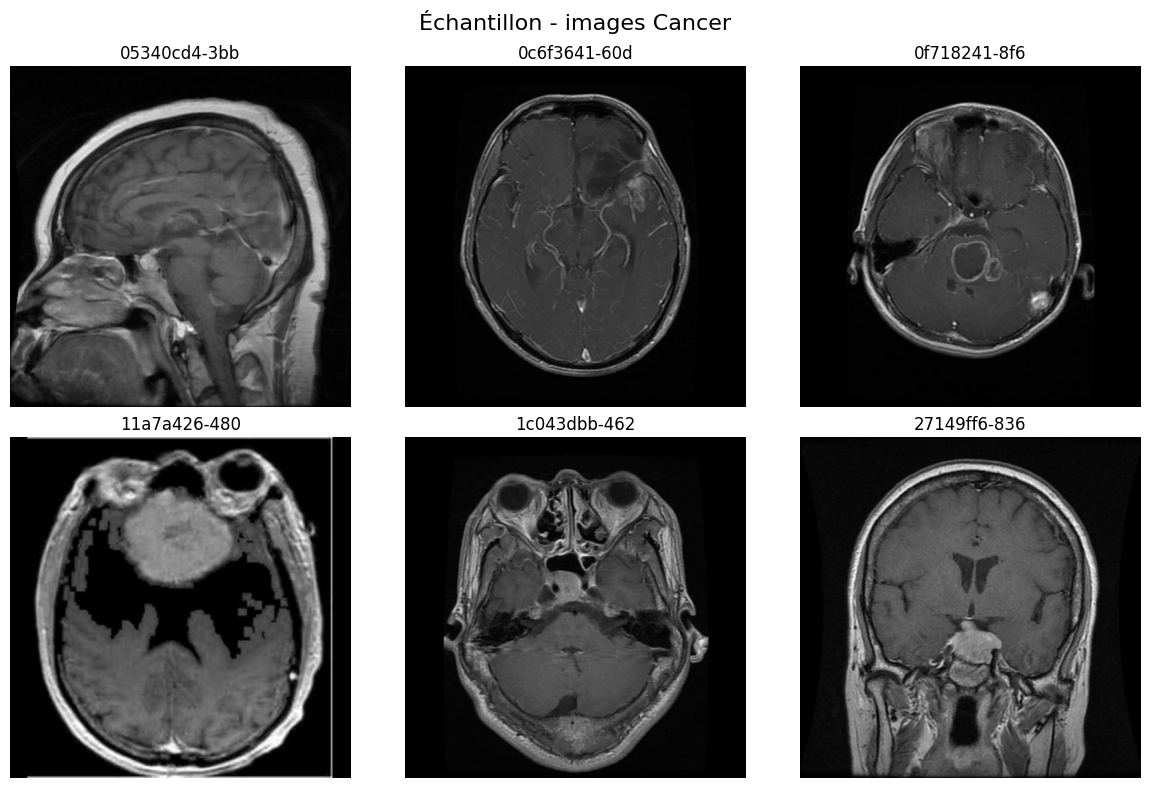

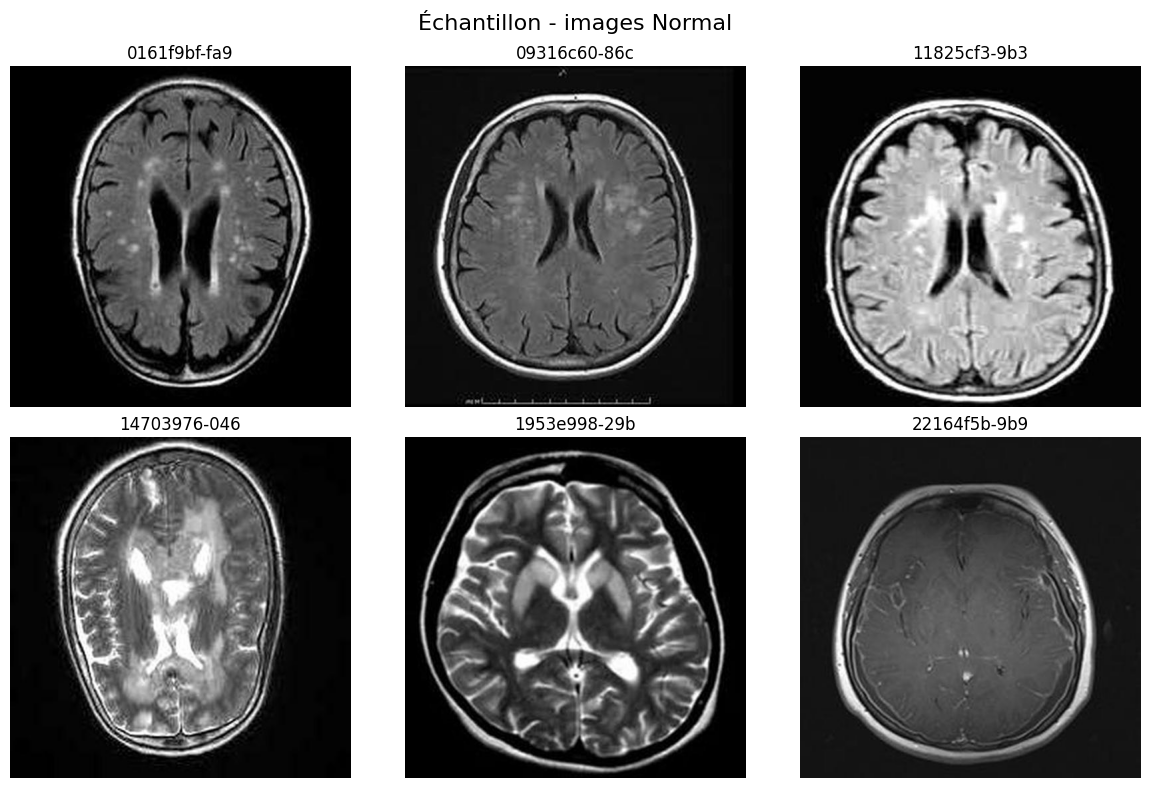

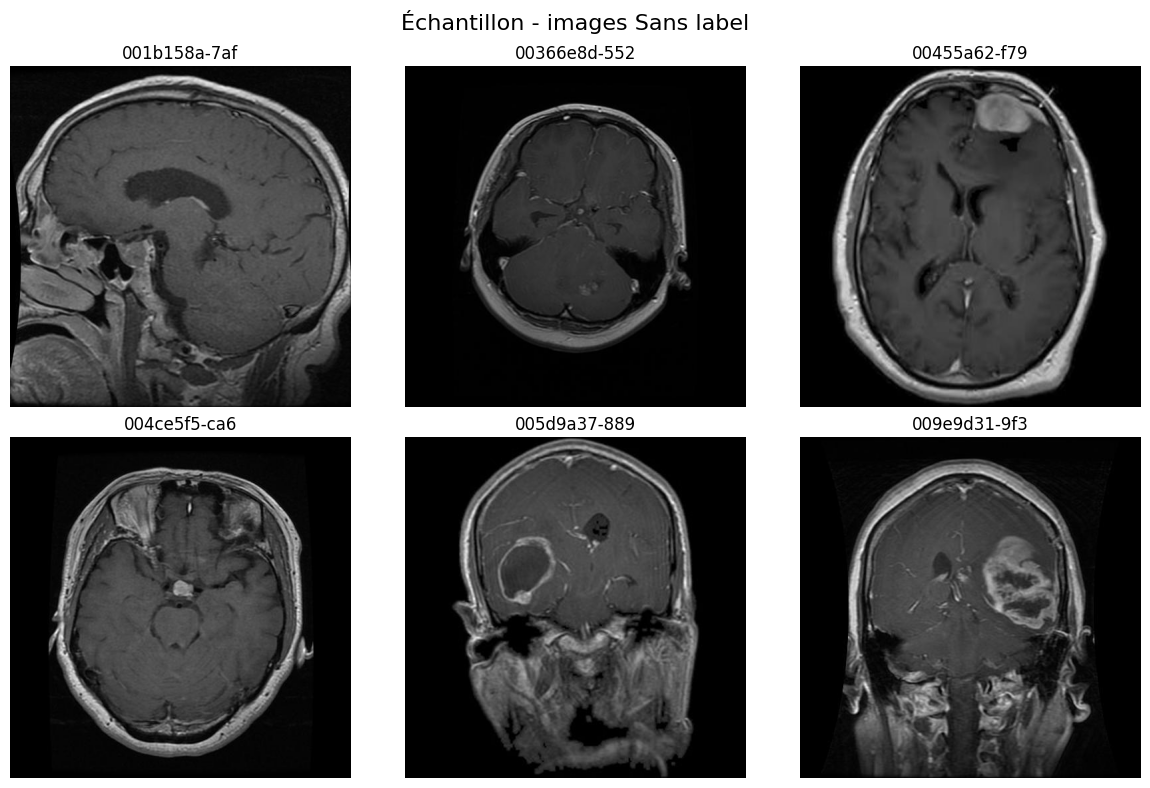

In [14]:
# Exploration visuelle d'un échantillon


import matplotlib.pyplot as plt
from PIL import Image

def show_samples(directory, title, n=6):
    image_paths = sorted(directory.glob("*.jpg"))[:n]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for ax, image_path in zip(axes, image_paths):
        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(image_path.name[:12])
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_samples(CANCER_DIR, "Échantillon - images Cancer")
show_samples(NORMAL_DIR, "Échantillon - images Normal")
show_samples(UNLABELED_DIR, "Échantillon - images Sans label")

# 2. Contrôle qualité et nettoyage

Cette section vérifie la présence éventuelle de doublons exacts dans le
jeu de données.

Les images fortement labellisées (`cancer` et `normal`) sont conservées
séparément des images sans label. Les doublons ne sont pas supprimés
automatiquement : leur présence est d'abord analysée afin d'éviter
d'introduire un biais dans les étapes de clustering et de
semi-supervision.


In [15]:
# Analyse des doublons entre les sous-ensembles

duplicate_cross_groups = (
    images_df.groupby("md5")["label"]
    .nunique()
)

cross_subset_duplicates = duplicate_cross_groups[
    duplicate_cross_groups > 1
]

print(
    "Nombre de groupes de doublons présents dans plusieurs sous-ensembles :",
    len(cross_subset_duplicates)
)

Nombre de groupes de doublons présents dans plusieurs sous-ensembles : 31


In [16]:
# Affichage des doublons présents entre plusieurs sous-ensembles

cross_duplicates_df = (
    images_df[
        images_df["md5"].isin(cross_subset_duplicates.index)
    ]
    .sort_values("md5")
)

display(
    cross_duplicates_df[
        ["label", "filename", "path", "md5"]
    ]
)

,label,filename,path,md5
76,normal,defdbef3-bea2-4f32-9d9a-62af1102ebfd.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,0652cb55477c4edeea5c5dfd53944e3b
1049,sans_label,b65c7ebe-aac9-414e-a9d3-b8205d5d5a23.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,0652cb55477c4edeea5c5dfd53944e3b
87,normal,9e761fb7-da77-4feb-b268-2d873293ee78.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,0816537db58c1d8092808f2c6f75e96c
578,sans_label,2f0c7977-339e-4e46-b412-c8fd1a8d05b0.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,0816537db58c1d8092808f2c6f75e96c
52,normal,595aa054-274a-4e4b-9a1b-c0c477c80463.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,1868801e49e6cd18fb2e4189250921e4
...,...,...,...,...
1361,sans_label,42d9ce05-9a99-4f86-b7fa-807a3f62396b.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,eaeb102cd99661f157923b9eff689053
86,normal,a0b8c8bc-8784-4af3-843c-f91b0d1e503f.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,f95511593d8fc69f9f0a7197cb1df0dd
1207,sans_label,8757de5e-a7df-4668-bf5a-547e22d4533a.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,f95511593d8fc69f9f0a7197cb1df0dd
62,normal,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,fa2f6066ee4f4e22f35c46c4ddf8584b


## Gestion des doublons et prévention de la fuite de données

Une vérification par empreinte MD5 a permis d'identifier des doublons exacts dans le dataset.

Deux situations sont distinguées :

- les doublons présents uniquement dans le sous-ensemble `sans_label` ;
- les doublons présents simultanément dans les données fortement labellisées (`cancer` ou `normal`) et dans `sans_label`.

Les doublons entre sous-ensembles sont particulièrement importants car ils pourraient provoquer une fuite de données entre les données fortement labellisées et les données faiblement labellisées.

Le dataset original est conservé sans modification. Les règles de nettoyage sont appliquées uniquement aux jeux de travail utilisés pour les étapes suivantes.

Lorsqu'une même image est présente dans un sous-ensemble fortement labellisé et dans `sans_label`, la version fortement labellisée est conservée et la copie `sans_label` est exclue du jeu utilisé pour le clustering.

Les doublons exacts présents uniquement dans `sans_label` sont également dédupliqués afin qu'une même image ne soit pas comptabilisée plusieurs fois dans l'analyse non supervisée.

In [17]:
# Gestion des doublons pour les jeux de travail


from pathlib import Path
import hashlib
import shutil
import pandas as pd

# Racine du dataset extrait
DATASET_ROOT = (
    Path("/mnt/projects/vk_oc_projet10_brainscanai")
    / "data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc"
)

LABELED_ROOT = DATASET_ROOT / "avec_labels"
UNLABELED_ROOT = DATASET_ROOT / "sans_label"

# ------------------------------------------------------------
# Fonction : calcul de l'empreinte MD5
# ------------------------------------------------------------

def md5_file(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()

    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            md5.update(chunk)

    return md5.hexdigest()


# ------------------------------------------------------------
# Construction d'un inventaire des images
# ------------------------------------------------------------

records = []

for label in ["cancer", "normal"]:
    for path in sorted((LABELED_ROOT / label).glob("*.jpg")):
        records.append({
            "label": label,
            "filename": path.name,
            "path": path,
            "md5": md5_file(path),
        })

for path in sorted(UNLABELED_ROOT.glob("*.jpg")):
    records.append({
        "label": "sans_label",
        "filename": path.name,
        "path": path,
        "md5": md5_file(path),
    })

df_images = pd.DataFrame(records)

print("Nombre total d'images :", len(df_images))
print()
print(df_images["label"].value_counts())

Nombre total d'images : 1506

label
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64


In [18]:
# Identification des doublons entre données labellisées et données sans label


# MD5 appartenant aux données fortement labellisées
md5_labeled = set(
    df_images.loc[
        df_images["label"].isin(["cancer", "normal"]),
        "md5"
    ]
)

# Images sans label dont le MD5 existe déjà dans les données labellisées
duplicates_with_labeled = df_images[
    (df_images["label"] == "sans_label")
    & (df_images["md5"].isin(md5_labeled))
].copy()

print(
    "Images sans label dupliquant une image fortement labellisée :",
    len(duplicates_with_labeled)
)

duplicates_with_labeled[["filename", "md5"]].head(20)

Images sans label dupliquant une image fortement labellisée : 32


,filename,md5
129,04dd2b78-0aa3-4364-b762-21a6e71d3658.jpg,34153b917f7b0535b60b20ae02adcbf8
234,16a16991-7c89-47c9-b96d-256ea1566f7c.jpg,7846208ea45ea9b11856e7dcdb98062f
248,18599c4b-13b7-434f-a6fc-4ab53c41aa95.jpg,1e2fd8da45a9cc434c617ae227ac9e27
251,194106ce-8b9a-4a6f-b82d-643f09169c9f.jpg,c33d9bfe54114ba89a9aefbd2f913e84
320,246f3294-b91c-47cf-9436-0c214197be2e.jpg,c544ce7a4227a08114007e31def727fb
369,2f0c7977-339e-4e46-b412-c8fd1a8d05b0.jpg,0816537db58c1d8092808f2c6f75e96c
436,3d09671b-9479-4ec9-a9cf-2934ad88657b.jpg,a631d5485b314887c98985a319b78789
471,42d9ce05-9a99-4f86-b7fa-807a3f62396b.jpg,eaeb102cd99661f157923b9eff689053
550,5408cb44-850a-49d9-8f6e-8e7d7d6ea44a.jpg,a2a734462cd31983c2402dba3305ffac
653,647895dc-e736-4a30-bc1b-71c5b3065b17.jpg,888fc6c20b83b53b2e9502fa8f7c3147


In [19]:
# Vérification des doublons au sein des données labellisées


labeled_df = df_images[
    df_images["label"].isin(["cancer", "normal"])
].copy()

labeled_duplicates = labeled_df[
    labeled_df.duplicated("md5", keep=False)
].sort_values("md5")

print(
    "Nombre de groupes de doublons dans les données fortement labellisées :",
    labeled_duplicates["md5"].nunique()
)

labeled_duplicates[["label", "filename", "md5"]]

Nombre de groupes de doublons dans les données fortement labellisées : 1


,label,filename,md5
77,normal,71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg,1e2fd8da45a9cc434c617ae227ac9e27
96,normal,d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg,1e2fd8da45a9cc434c617ae227ac9e27


## Gestion des doublons et prévention de la fuite de données

Une analyse par empreinte MD5 a été réalisée afin d'identifier les doublons exacts.

32 images du sous-ensemble `sans_label` correspondent exactement à des images
présentes dans les données fortement labellisées (`cancer` ou `normal`).

Afin d'éviter toute fuite de données entre les jeux fortement et faiblement
labellisés, ces 32 copies ne seront pas utilisées dans le jeu `sans_label`
destiné au clustering.

Un doublon exact a également été détecté au sein des données fortement
labellisées. Les deux fichiers correspondent à la même image et portent le
même label `normal`.

Le dataset original est conservé sans modification. Le nettoyage est réalisé
dans un jeu de travail dédié.

In [20]:
# Construction du jeu de travail sans doublons


# 1. Données fortement labellisées
labeled_df = df_images[
    df_images["label"].isin(["cancer", "normal"])
].copy()

# 2. Données sans label
unlabeled_df = df_images[
    df_images["label"] == "sans_label"
].copy()

# Suppression des copies présentes dans les données labellisées


md5_labeled = set(labeled_df["md5"])

unlabeled_without_labeled_duplicates = unlabeled_df[
    ~unlabeled_df["md5"].isin(md5_labeled)
].copy()

print("Images sans label initiales :", len(unlabeled_df))
print(
    "Copies d'images labellisées exclues :",
    len(unlabeled_df) - len(unlabeled_without_labeled_duplicates)
)
print(
    "Images sans label restantes :",
    len(unlabeled_without_labeled_duplicates)
)

Images sans label initiales : 1406
Copies d'images labellisées exclues : 32
Images sans label restantes : 1374


In [21]:
# Recherche des doublons restant dans le jeu sans label


duplicate_unlabeled = (
    unlabeled_without_labeled_duplicates[
        unlabeled_without_labeled_duplicates.duplicated(
            subset="md5",
            keep=False
        )
    ]
    .sort_values("md5")
)

print(
    "Nombre de groupes de doublons dans le jeu sans label :",
    duplicate_unlabeled["md5"].nunique()
)

print(
    "Nombre de fichiers concernés :",
    len(duplicate_unlabeled)
)

duplicate_unlabeled[["filename", "md5"]].head(30)

Nombre de groupes de doublons dans le jeu sans label : 59
Nombre de fichiers concernés : 122


,filename,md5
651,63f74ae7-15f3-40e6-90f8-850dd20dbb70.jpg,038bd3a36c6463f3a9f18ac031ea1c4d
988,a74cd797-2401-44e9-b29b-e3e125c8e148.jpg,038bd3a36c6463f3a9f18ac031ea1c4d
195,0f8e0e52-d574-48d4-91a4-9bd2ae88b4c6.jpg,130893ec3b6f15fd489fc2ece20323b8
661,6617f4da-4eff-47cd-b82b-e805cf91133f.jpg,130893ec3b6f15fd489fc2ece20323b8
179,0d76d3dc-2285-4901-94c9-ee2fc0773dad.jpg,15ab418722ae8ce42490285b7c5de7d3
1045,afae92bf-17c8-4ffa-ab32-3fb29c79a586.jpg,15ab418722ae8ce42490285b7c5de7d3
173,0c62cd9f-f625-4fc3-8e93-264a2436701c.jpg,246a25a4d05b67b63c41b0c27f9204bf
1307,de19d8fc-0059-4bbe-b6df-d10b68613494.jpg,246a25a4d05b67b63c41b0c27f9204bf
999,a99cffba-c2d8-422b-9ef7-87390609ce8f.jpg,2784a33f36aba71599f3126cd45f37d1
1200,cae04dd3-0b80-44f6-b7cf-e063e6ee3b41.jpg,2784a33f36aba71599f3126cd45f37d1


In [22]:
# Taille des groupes de doublons dans le jeu sans label

duplicate_group_sizes = (
    duplicate_unlabeled
    .groupby("md5")
    .size()
    .value_counts()
    .sort_index()
)

print("Répartition du nombre de fichiers par groupe de doublons :")
print(duplicate_group_sizes)

print()
print("Nombre total de groupes :", duplicate_unlabeled["md5"].nunique())
print("Nombre total de fichiers concernés :", len(duplicate_unlabeled))

Répartition du nombre de fichiers par groupe de doublons :
2    55
3     4
Name: count, dtype: int64

Nombre total de groupes : 59
Nombre total de fichiers concernés : 122


In [23]:
# Construction des jeux analytiques sans doublons

# 1. Images fortement labellisées


labeled_df = df_images[
    df_images["label"].isin(["cancer", "normal"])
].copy()

# Un seul représentant par image exacte (MD5)
labeled_unique_df = (
    labeled_df
    .drop_duplicates(subset="md5", keep="first")
    .reset_index(drop=True)
)

# 2. Images sans label


unlabeled_df = df_images[
    df_images["label"] == "sans_label"
].copy()

# Exclusion des copies exactes d'images déjà labellisées
unlabeled_clean_df = unlabeled_df[
    ~unlabeled_df["md5"].isin(set(labeled_df["md5"]))
].copy()

# Un seul représentant par groupe de doublons exacts
unlabeled_unique_df = (
    unlabeled_clean_df
    .drop_duplicates(subset="md5", keep="first")
    .reset_index(drop=True)
)

# 3. Résumé


print("Jeux analytiques construits")
print("=" * 55)

print(
    f"Images fortement labellisées originales : {len(labeled_df)}"
)
print(
    f"Images fortement labellisées uniques    : {len(labeled_unique_df)}"
)

print()

print(
    f"Images sans label originales            : {len(unlabeled_df)}"
)
print(
    f"Images sans label après exclusion copies: "
    f"{len(unlabeled_clean_df)}"
)
print(
    f"Images sans label uniques               : "
    f"{len(unlabeled_unique_df)}"
)

Jeux analytiques construits
Images fortement labellisées originales : 100
Images fortement labellisées uniques    : 99

Images sans label originales            : 1406
Images sans label après exclusion copies: 1374
Images sans label uniques               : 1311


L'inventaire analytique est maintenant clairement défini :

- 100 fichiers labellisés dans la source
- 99 images labellisées uniques
- 1 406 fichiers sans label
- 32 copies exactes d'images labellisées retirées du pool sans label
- 1 374 images sans label restantes
- 59 groupes de doublons exacts dans ces 1 374 images
- 1 311 images sans label uniques

**La décision est donc :** source brute conservée intégralement + jeux analytiques dédupliqués utilisés pour les étapes ML.

In [24]:
# Vérification finale : absence de chevauchement entre les jeux fortement labellisé et sans label


labeled_md5 = set(labeled_unique_df["md5"])
unlabeled_md5 = set(unlabeled_unique_df["md5"])

overlap_md5 = labeled_md5.intersection(unlabeled_md5)

print("Vérification d'intégrité des jeux analytiques")
print("=" * 55)
print(f"Images labellisées uniques : {len(labeled_md5)}")
print(f"Images sans label uniques  : {len(unlabeled_md5)}")
print(f"Images communes aux deux jeux : {len(overlap_md5)}")

if len(overlap_md5) == 0:
    print("\nAucun chevauchement détecté.")
    print("Les deux jeux analytiques sont indépendants.")
else:
    print("\nChevauchement détecté !")
    print("MD5 concernés :", overlap_md5)

Vérification d'intégrité des jeux analytiques
Images labellisées uniques : 99
Images sans label uniques  : 1311
Images communes aux deux jeux : 0

Aucun chevauchement détecté.
Les deux jeux analytiques sont indépendants.


### Contrôle qualité du jeu de données

La documentation initiale annonce un corpus de **1 500 images**, composé de **1 400 images sans label** et de **100 images labellisées**. L’archive effectivement fournie contient toutefois **1 506 images**.

L’analyse du corpus a mis en évidence :

- **32 copies exactes** d’images labellisées présentes dans le sous-ensemble sans label, susceptibles d’introduire une **fuite de données** ;
- plusieurs **groupes de doublons exacts** au sein des images sans label.

Afin de garantir l’intégrité du protocole expérimental, les copies d’images labellisées ont été exclues du pool sans label et les doublons exacts ont été dédupliqués.

Le **jeu analytique retenu** comprend ainsi :

- **99 images labellisées uniques** ;
- **1 311 images sans label uniques**.

> **Décision :** les fichiers sources sont conservés intégralement afin d’assurer la traçabilité et la reproductibilité des traitements. Les jeux dédupliqués sont utilisés exclusivement pour les étapes d’analyse et d’apprentissage automatique (ML).

# Synthèse de l'étape 1

## 1A. Vue d'ensemble du jeu de données

Le jeu de données fourni dans le cadre du projet **BrainScanAI** est organisé en trois sous-ensembles :

- `avec_labels/cancer/` : images fortement labellisées avec la classe `cancer` ;
- `avec_labels/normal/` : images fortement labellisées avec la classe `normal` ;
- `sans_label/` : images ne disposant pas de label.

La documentation associée au dataset annonce **1 500 images**, réparties entre **100 images labellisées** et **1 400 images sans label**.

L'inspection de l'archive fournie montre toutefois une différence entre la documentation et les données réellement disponibles.

| Sous-ensemble | Documentation | Données observées |
|---|---:|---:|
| `cancer` | 50 | 50 |
| `normal` | 50 | 50 |
| `sans_label` | 1 400 | 1 406 |
| **Total** | **1 500** | **1 506** |

Le dataset contient donc **6 images supplémentaires**, toutes présentes dans le sous-ensemble `sans_label`.

Cette différence est conservée dans l'analyse afin d'assurer la traçabilité entre les données fournies et les données effectivement utilisées.



## 1B. Exploration visuelle

Une exploration visuelle a été réalisée sur un **échantillon de 18 images** provenant des différents sous-ensembles.

Cette exploration permet de vérifier :

- l'apparence générale des images ;
- la cohérence visuelle du dataset ;
- la présence éventuelle d'images manifestement incorrectes ou illisibles ;
- la différence visuelle entre les catégories `cancer` et `normal` ;
- la diversité des images disponibles.

Cette première inspection confirme que les fichiers correspondent bien à des images cérébrales destinées à l'analyse du problème étudié.

> **Limite importante :** l'exploration visuelle seule ne permet pas de conclure à la présence ou à l'absence d'une tumeur. Dans le cadre de ce projet, les observations visuelles servent uniquement au contrôle exploratoire des données et non à l'établissement d'un diagnostic médical.



## 1C. Résolution, format et canaux de couleur

Les contrôles effectués sur les fichiers montrent une cohérence des caractéristiques techniques des images.

Les images sont :

- au format **JPEG/JPG** ;
- de résolution **512 × 512 pixels** ;
- compatibles avec leur traitement ultérieur par des modèles de vision pré-entraînés ;
- correctement lisibles avec la bibliothèque **Pillow**.

Le contrôle des canaux de couleur a également été réalisé afin d'identifier le mode d'image utilisé et de préparer correctement les transformations nécessaires à l'étape d'extraction des features.

Ces vérifications sont importantes avant d'appliquer un modèle pré-entraîné, car les transformations d'entrée doivent être compatibles avec le format attendu par celui-ci.



## 1D. Contrôle de la qualité et des doublons

Un contrôle supplémentaire de l'intégrité des données a été réalisé à l'aide d'une empreinte **MD5** calculée pour chaque fichier.

Cette analyse a permis d'identifier plusieurs situations importantes.

### 1D1. Doublons entre les sous-ensembles

**32 fichiers du sous-ensemble `sans_label` sont des copies exactes d'images déjà présentes dans les données fortement labellisées.**

Ces fichiers ne doivent pas être considérés comme de nouvelles observations indépendantes.

Ils sont donc exclus du pool utilisé pour les analyses sur les données sans label afin de limiter le risque de **fuite de données** lors des étapes ultérieures.

### 1D2 Doublons internes au sous-ensemble `sans_label`

Après exclusion des copies d'images labellisées :

- **59 groupes de doublons exacts** ont été identifiés ;
- **122 fichiers** sont concernés ;
- 55 groupes contiennent 2 fichiers ;
- 4 groupes contiennent 3 fichiers.

En conservant un seul représentant par groupe de doublons, cela correspond à **63 fichiers redondants**.

Le nombre d'images sans label uniques utilisées pour l'analyse est donc :

**1 374 - 63 = 1 311 images.**

### 1D3. Doublon dans les données fortement labellisées

Un groupe de doublons exacts a également été identifié dans les données fortement labellisées.

Les deux fichiers concernés appartiennent à la classe `normal`.

Ainsi, les **100 fichiers labellisés** correspondent à **99 images uniques**.

Cette situation est conservée dans la documentation du projet plutôt que masquée, car elle constitue une information importante concernant la qualité réelle du dataset.



## 1E. Constitution des jeux analytiques

Afin de préserver les données originales tout en disposant de données adaptées aux analyses de machine learning, aucune suppression physique n'a été effectuée dans le dataset source.

Le principe retenu est le suivant :

> **Les données brutes sont conservées intactes et les règles de nettoyage sont appliquées au niveau des jeux analytiques.**

Les jeux utilisés pour les étapes suivantes sont donc :

| Jeu analytique | Nombre d'images | Traitement |
|---|---:|---|
| Images fortement labellisées | **99** | Doublons exacts dédupliqués |
| Images sans label | **1 311** | Copies des images labellisées exclues + doublons exacts dédupliqués |

Une dernière vérification par empreinte MD5 a confirmé qu'il n'existe **aucun chevauchement exact** entre les deux jeux analytiques.

**Nombre d'images communes : 0.**

Les deux populations sont donc indépendantes au niveau des doublons exacts détectables par MD5.



## 1F. Bilan de l'étape d'exploration

L'exploration réalisée permet de conclure que le jeu de données est globalement cohérent avec le cas d'usage présenté, tout en présentant plusieurs particularités qui doivent être prises en compte dans la suite du projet :

1. le nombre réel d'images diffère de celui indiqué dans la documentation ;
2. des copies exactes d'images labellisées étaient présentes dans le sous-ensemble sans label ;
3. plusieurs groupes de doublons exacts existent dans les données sans label ;
4. un doublon exact existe dans les données fortement labellisées ;
5. les fichiers sources sont conservés afin de garantir la traçabilité ;
6. des jeux analytiques dédupliqués et indépendants ont été constitués.

Ces contrôles permettent de réduire les risques de **fuite de données**, de surpondération de certaines observations et de biais liés à la présence de doublons avant d'aborder les étapes de modélisation.


## 1G. Conclusion — Étape 1 

L'étape d'exploration du jeu de données est considérée comme **validée**.

Les éléments demandés ont été réalisés :

- chargement et inspection du dataset ;
- vérification de la structure des fichiers ;
- exploration visuelle sur un échantillon ;
- vérification de la résolution ;
- vérification des caractéristiques des images et des canaux ;
- contrôle de la lisibilité et de la cohérence des fichiers ;
- analyse de la qualité des données ;
- identification et traitement analytique des doublons ;
- documentation des écarts entre la documentation et les données réellement fournies.

Les données sont maintenant suffisamment caractérisées pour passer à l'étape suivante :

> **Étape 2 — Prétraitement des images et extraction de features à l'aide d'un modèle pré-entraîné.**

Cette étape permettra de transformer les images en représentations numériques (*embeddings*) exploitables pour l'analyse non supervisée et les approches semi-supervisées qui suivront.

# Étape 2 — Prétraitement des images et extraction des features

## Objectif

L'objectif de cette étape est de transformer les images cérébrales en représentations numériques (*embeddings*) exploitables par les méthodes d'analyse non supervisée qui seront utilisées dans la suite du projet.

La démarche retenue est la suivante :

**Images → Prétraitement → Modèle CNN pré-entraîné → Embeddings visuels**

Un modèle **ResNet-50 pré-entraîné sur ImageNet** sera utilisé comme première architecture de référence pour l'extraction des caractéristiques visuelles.

Le choix d'un modèle pré-entraîné permet d'exploiter des représentations visuelles déjà apprises sur un large corpus d'images, sans nécessiter l'entraînement complet d'un réseau profond à partir des seules données fortement labellisées disponibles dans ce projet.



## Données utilisées

Les contrôles réalisés lors de l'étape précédente ont permis de constituer deux jeux analytiques indépendants :

- **99 images fortement labellisées uniques** ;
- **1 311 images sans label uniques**.

Les fichiers sources originaux sont conservés dans leur état initial. Les règles de nettoyage et de déduplication sont appliquées au niveau analytique.



## Prétraitement

Les images seront transformées afin de respecter les contraintes d'entrée du modèle pré-entraîné.

Les principales opérations seront :

- conversion dans un espace couleur compatible avec le modèle ;
- redimensionnement des images ;
- transformation adaptée à la taille d'entrée du réseau ;
- normalisation à l'aide des statistiques utilisées lors du pré-entraînement sur ImageNet.

Les transformations seront appliquées de manière identique aux images fortement labellisées et aux images sans label afin de garantir la comparabilité des embeddings.



## Extraction des features

Les couches convolutionnelles du modèle seront **gelées** afin d'utiliser ResNet-50 comme extracteur de caractéristiques et non comme modèle entraîné à partir de zéro.

Les sorties du réseau seront ensuite converties en vecteurs numériques appelés **embeddings**.

Ces vecteurs constitueront la représentation des images utilisée lors de l'analyse non supervisée.



## Contrôles prévus

Avant de poursuivre vers le clustering, plusieurs contrôles seront réalisés :

1. vérifier la compatibilité des images avec les transformations ;
2. vérifier la dimension des vecteurs extraits ;
3. vérifier l'absence de valeurs `NaN` ou infinies ;
4. vérifier que les dimensions des embeddings sont cohérentes entre les deux jeux ;
5. analyser la distribution des features ;
6. sauvegarder les embeddings dans un format exploitable pour les étapes suivantes.

Une attention particulière sera portée à la **reproductibilité** et à la **traçabilité** des transformations utilisées.



## Justification méthodologique

Cette approche répond aux contraintes du projet :

- nombre limité d'images fortement labellisées ;
- présence d'un volume plus important d'images sans label ;
- nécessité d'obtenir une représentation visuelle exploitable par des méthodes de clustering ;
- besoin de limiter l'entraînement d'un modèle profond sur un faible volume de labels.

L'extraction de features constitue ainsi une étape intermédiaire entre les images brutes et l'analyse non supervisée.

> **Remarque :** cette étude est réalisée dans un objectif exploratoire de faisabilité en traitement d'images. Les embeddings et les modèles développés dans ce projet ne constituent pas un dispositif médical ni un outil de diagnostic clinique.

2.1 — Analyse de l'exposition des images
Nombre total d'images analysées : 1410

Statistiques des intensités
----------------------------------------------------------------------
Moyenne   : 51.77
Médiane   : 47
Percentile 1 %  : 0
Percentile 99 % : 223


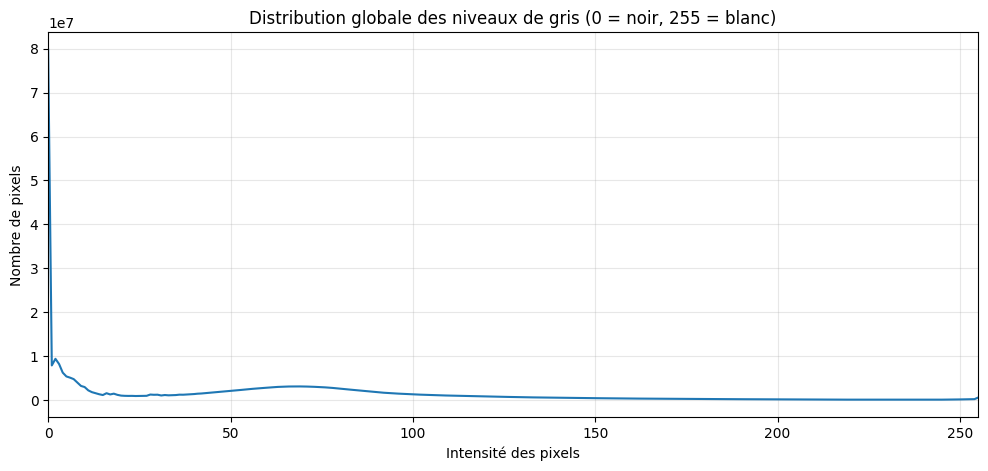


✓ Histogramme global calculé.
✓ Distribution des pixels observée sur l'ensemble analytique.
✓ Aucune transformation CLAHE appliquée à ce stade.


In [25]:
# ======================================================================
# 2.1 — Analyse de la distribution des niveaux de gris
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 70)
print("2.1 — Analyse de l'exposition des images")
print("=" * 70)

# ----------------------------------------------------------------------
# Sélection d'un échantillon représentatif
# ----------------------------------------------------------------------

# On utilise uniquement les images disponibles dans les deux jeux
# analytiques déjà nettoyés.
analysis_df = pd.concat(
    [
        labeled_unique_df.assign(dataset="labeled"),
        unlabeled_unique_df.assign(dataset="unlabeled")
    ],
    ignore_index=True
)

print(f"Nombre total d'images analysées : {len(analysis_df)}")

# ----------------------------------------------------------------------
# Calcul de l'histogramme global des intensités
# ----------------------------------------------------------------------

hist_global = np.zeros(256, dtype=np.int64)

for path in analysis_df["path"]:

    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Impossible de lire l'image : {path}")

    hist = cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    ).flatten()

    hist_global += hist.astype(np.int64)

# ----------------------------------------------------------------------
# Statistiques globales
# ----------------------------------------------------------------------

total_pixels = hist_global.sum()

mean_intensity = (
    np.arange(256) * hist_global
).sum() / total_pixels

median_intensity = np.searchsorted(
    np.cumsum(hist_global),
    total_pixels / 2
)

p01 = np.searchsorted(
    np.cumsum(hist_global),
    total_pixels * 0.01
)

p99 = np.searchsorted(
    np.cumsum(hist_global),
    total_pixels * 0.99
)

print()
print("Statistiques des intensités")
print("-" * 70)
print(f"Moyenne   : {mean_intensity:.2f}")
print(f"Médiane   : {median_intensity}")
print(f"Percentile 1 %  : {p01}")
print(f"Percentile 99 % : {p99}")

# ----------------------------------------------------------------------
# Visualisation de la distribution
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(256),
    hist_global
)

plt.xlim(0, 255)

plt.xlabel("Intensité des pixels")
plt.ylabel("Nombre de pixels")

plt.title(
    "Distribution globale des niveaux de gris "
    "(0 = noir, 255 = blanc)"
)

plt.grid(alpha=0.3)

plt.show()

print()
print("✓ Histogramme global calculé.")
print("✓ Distribution des pixels observée sur l'ensemble analytique.")
print("✓ Aucune transformation CLAHE appliquée à ce stade.")

Le résultat obtenu justifie une analyse CLAHE : la moyenne (51,77) et la médiane (47) sont relativement basses sur une plage de 0–255, et on observe visuellement une **concentration à gauche de la distribution**. Cela suggère un contraste/exposition plutôt faibles. Il faut donc maintenant vérifier si CLAHE améliore réellement la répartition des intensités.

### Contrôle visuel après CLAHE

Sur les images **après CLAHE**, nous voulons vérifier visuellement si :

- les structures cérébrales deviennent mieux distinguables ;
- le contraste local est amélioré ;
- les zones très sombres ne sont pas excessivement amplifiées ;
- les images ne deviennent pas artificiellement bruitées.


2.2 — Comparaison avant / après CLAHE


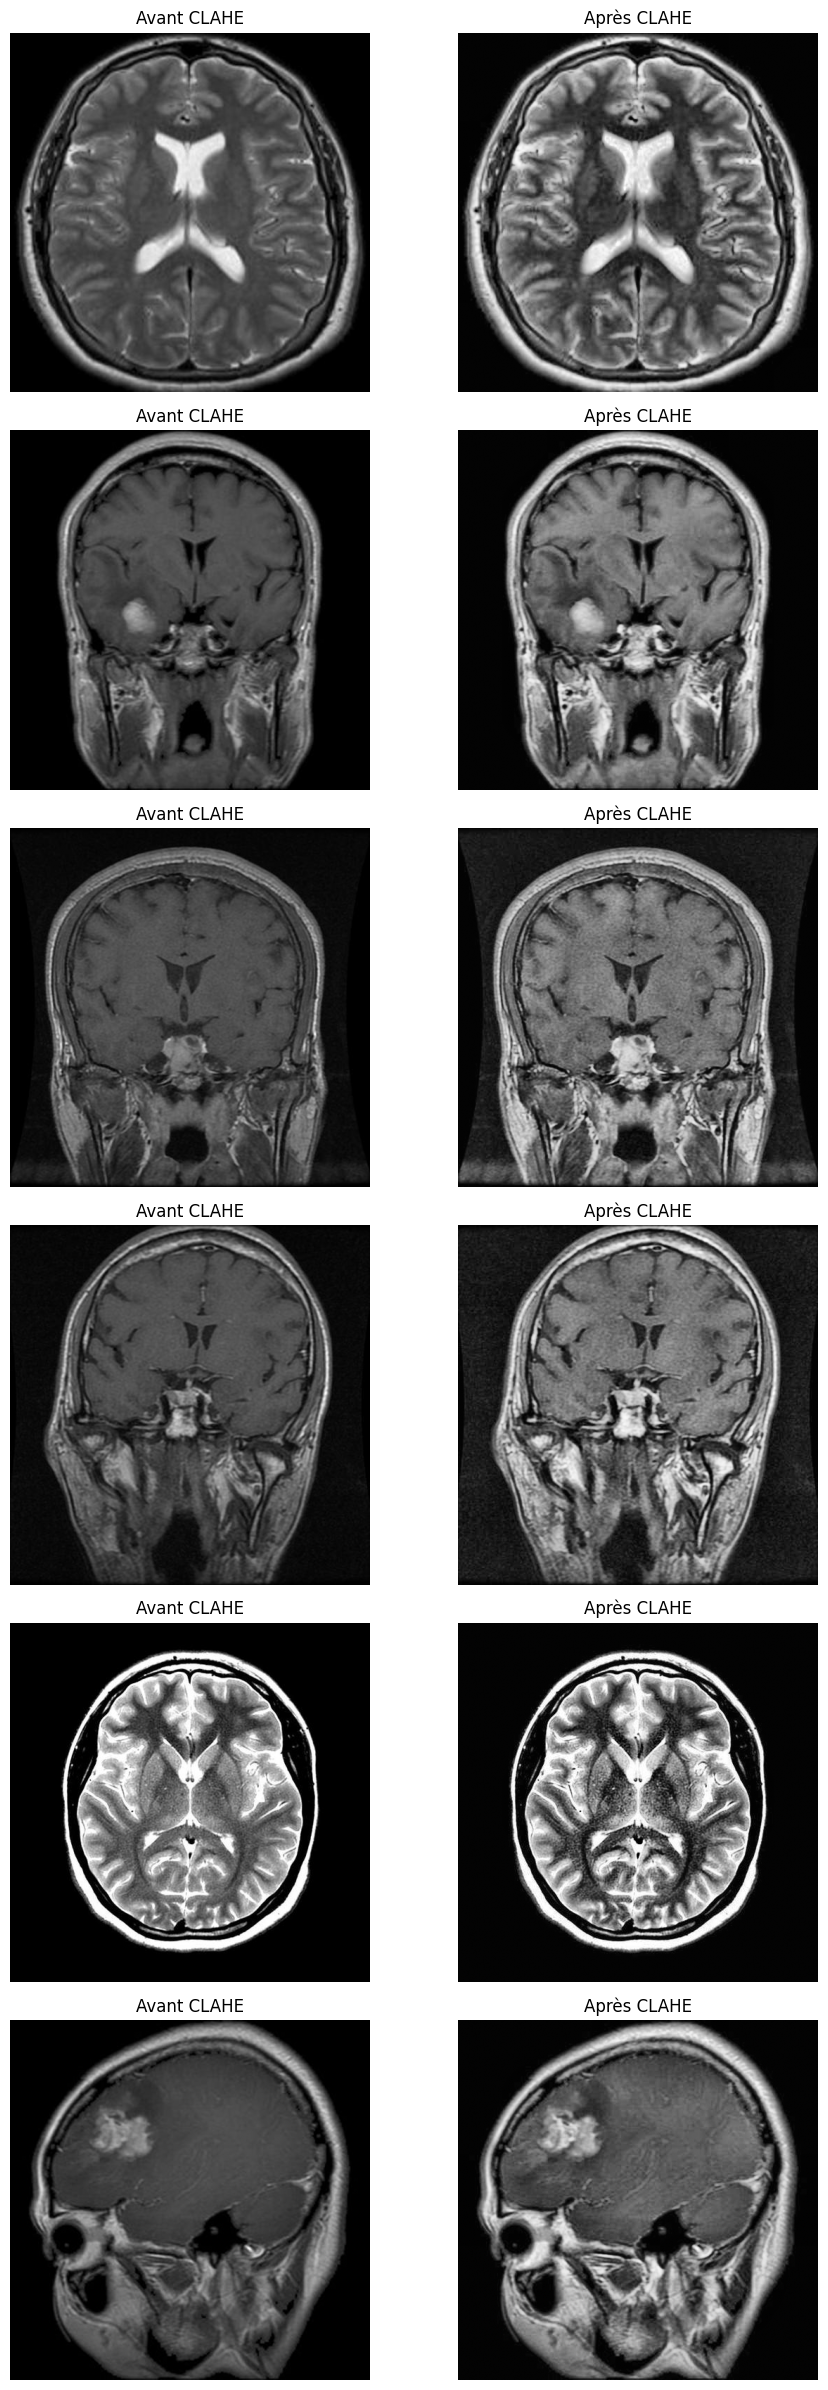


Comparaison des intensités
----------------------------------------------------------------------

Image : 2e0fca33-43ed-4b12-b24e-3d232e89c380.jpg
Avant CLAHE → moyenne : 66.80 | min : 0 | max : 251
Après CLAHE → moyenne : 85.42 | min : 0 | max : 254

Image : 95055fe4-5c47-4591-85ff-422cdbd3ff0c.jpg
Avant CLAHE → moyenne : 47.35 | min : 0 | max : 248
Après CLAHE → moyenne : 71.08 | min : 1 | max : 254

Image : ee0737c2-8bbd-4a77-b531-dd8fa5e3dcd9.jpg
Avant CLAHE → moyenne : 51.84 | min : 0 | max : 248
Après CLAHE → moyenne : 80.02 | min : 1 | max : 252

Image : 0f716a6b-8467-459c-bf58-4d34e9439d1d.jpg
Avant CLAHE → moyenne : 52.01 | min : 0 | max : 255
Après CLAHE → moyenne : 81.01 | min : 0 | max : 255

Image : 8411d424-f38c-497c-aeab-30213125a487.jpg
Avant CLAHE → moyenne : 64.45 | min : 0 | max : 255
Après CLAHE → moyenne : 64.10 | min : 0 | max : 255

Image : 52f16dc2-f3c0-499c-9a50-59e02341b0fa.jpg
Avant CLAHE → moyenne : 52.06 | min : 0 | max : 249
Après CLAHE → moyenne : 72.54

In [26]:
# Test de la fonction CLAHE sur un échantillon

# ======================================================================
# 2.2 — Comparaison avant / après CLAHE
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 70)
print("2.2 — Comparaison avant / après CLAHE")
print("=" * 70)

# ----------------------------------------------------------------------
# Sélection de quelques images représentatives
# ----------------------------------------------------------------------

sample_paths = analysis_df["path"].sample(
    n=min(6, len(analysis_df)),
    random_state=42
).tolist()

# ----------------------------------------------------------------------
# Paramètres CLAHE
# ----------------------------------------------------------------------

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# ----------------------------------------------------------------------
# Affichage avant / après
# ----------------------------------------------------------------------

fig, axes = plt.subplots(
    len(sample_paths),
    2,
    figsize=(10, 4 * len(sample_paths))
)

if len(sample_paths) == 1:
    axes = np.array([axes])

for i, path in enumerate(sample_paths):

    # Lecture en niveaux de gris
    image_gray = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image_gray is None:
        raise ValueError(
            f"Impossible de lire l'image : {path}"
        )

    # Application de CLAHE
    image_clahe = clahe.apply(image_gray)

    # Affichage image originale
    axes[i, 0].imshow(
        image_gray,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[i, 0].set_title("Avant CLAHE")
    axes[i, 0].axis("off")

    # Affichage image après CLAHE
    axes[i, 1].imshow(
        image_clahe,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[i, 1].set_title("Après CLAHE")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# Comparaison des statistiques
# ----------------------------------------------------------------------

print()
print("Comparaison des intensités")
print("-" * 70)

for path in sample_paths:

    image_gray = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    image_clahe = clahe.apply(image_gray)

    print()
    print(f"Image : {Path(path).name}")

    print(
        f"Avant CLAHE → "
        f"moyenne : {image_gray.mean():.2f} | "
        f"min : {image_gray.min()} | "
        f"max : {image_gray.max()}"
    )

    print(
        f"Après CLAHE → "
        f"moyenne : {image_clahe.mean():.2f} | "
        f"min : {image_clahe.min()} | "
        f"max : {image_clahe.max()}"
    )

print()
print("✓ Comparaison visuelle avant/après CLAHE réalisée.")
print("✓ Aucun embedding ResNet-50 n'a encore été modifié.")
print("✓ Les paramètres CLAHE sont explicitement documentés.")



Sur **5 images sur 6**, CLAHE augmente nettement la moyenne des intensités :

- 66,80 → **85,42**
- 47,35 → **71,08**
- 51,84 → **80,02**
- 52,01 → **81,01**
- 52,06 → **72,54**

Une image est quasiment inchangée :

- 64,45 → **64,10**

Cela est cohérent avec la première observation : **une partie importante des images présente une distribution plutôt concentrée vers les faibles intensités**, et CLAHE améliore localement le contraste.

> **Néanmoins attention:** une augmentation de la moyenne n'est pas en soi la preuve que l'image est meilleure. CLAHE améliore surtout le **contraste local** ; il ne faut donc pas présenter cela comme une simple « correction de sous-exposition ».

Nous devons maintenant **quantifier l'effet sur la distribution des pixels avant/après** en réalisant un histogramme global avant / après CLAHE.

CLAHE sera appliqué aux **1 410 images** pour comparer :

- l'histogramme global avant ;
- l'histogramme global après ;
- la moyenne ;
- la médiane ;
- les percentiles ;
- éventuellement, la proportion de pixels dans les zones très sombres et très claires.

2.3 — Distribution globale avant / après CLAHE

Statistiques globales
----------------------------------------------------------------------
Indicateur                   Avant CLAHE    Après CLAHE
----------------------------------------------------------------------
Moyenne                            51.77          71.53
Médiane                               47             64
Percentile 1 %                         0              2
Percentile 99 %                      223            234
Pixels sombres < 32               44.03%         40.77%
Pixels clairs >= 224               0.99%          1.74%


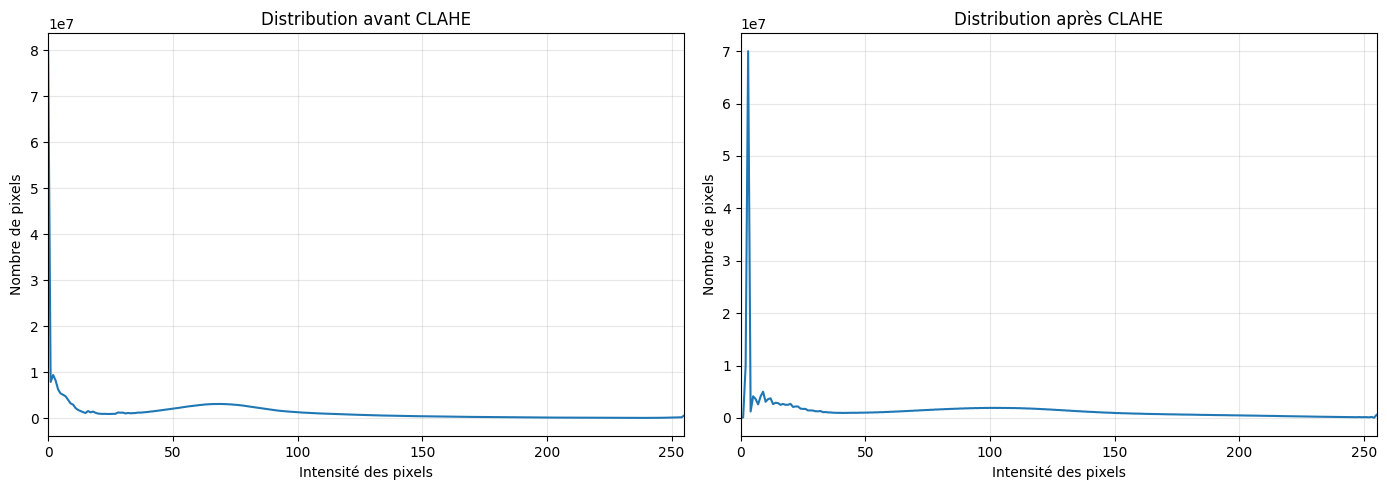


✓ Histogrammes globaux avant/après CLAHE calculés.
✓ Statistiques comparatives calculées.
✓ Aucune modification du pipeline ResNet-50.


In [27]:
# ======================================================================
# 2.3 — Analyse globale de l'effet de CLAHE sur la distribution des pixels
# ======================================================================

print("=" * 70)
print("2.3 — Distribution globale avant / après CLAHE")
print("=" * 70)

# ----------------------------------------------------------------------
# Initialisation des histogrammes
# ----------------------------------------------------------------------

hist_before = np.zeros(256, dtype=np.int64)
hist_after = np.zeros(256, dtype=np.int64)

# Même configuration CLAHE que précédemment
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# ----------------------------------------------------------------------
# Parcours des 1 410 images
# ----------------------------------------------------------------------

for path in analysis_df["path"]:

    image_gray = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image_gray is None:
        raise ValueError(
            f"Impossible de lire l'image : {path}"
        )

    # Histogramme avant CLAHE
    hist_before += np.bincount(
        image_gray.ravel(),
        minlength=256
    )

    # Application de CLAHE
    image_clahe = clahe.apply(image_gray)

    # Histogramme après CLAHE
    hist_after += np.bincount(
        image_clahe.ravel(),
        minlength=256
    )

# ----------------------------------------------------------------------
# Fonction de calcul des statistiques
# ----------------------------------------------------------------------

def intensity_statistics(histogram):

    total = histogram.sum()
    cumulative = np.cumsum(histogram)

    mean = (
        np.arange(256) * histogram
    ).sum() / total

    median = np.searchsorted(
        cumulative,
        total / 2
    )

    p01 = np.searchsorted(
        cumulative,
        total * 0.01
    )

    p99 = np.searchsorted(
        cumulative,
        total * 0.99
    )

    dark_ratio = histogram[:32].sum() / total
    bright_ratio = histogram[224:].sum() / total

    return {
        "mean": mean,
        "median": median,
        "p01": p01,
        "p99": p99,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio
    }


stats_before = intensity_statistics(hist_before)
stats_after = intensity_statistics(hist_after)

# ----------------------------------------------------------------------
# Affichage des statistiques
# ----------------------------------------------------------------------

print("\nStatistiques globales")
print("-" * 70)

print(
    f"{'Indicateur':<25}"
    f"{'Avant CLAHE':>15}"
    f"{'Après CLAHE':>15}"
)

print("-" * 70)

print(
    f"{'Moyenne':<25}"
    f"{stats_before['mean']:>15.2f}"
    f"{stats_after['mean']:>15.2f}"
)

print(
    f"{'Médiane':<25}"
    f"{stats_before['median']:>15}"
    f"{stats_after['median']:>15}"
)

print(
    f"{'Percentile 1 %':<25}"
    f"{stats_before['p01']:>15}"
    f"{stats_after['p01']:>15}"
)

print(
    f"{'Percentile 99 %':<25}"
    f"{stats_before['p99']:>15}"
    f"{stats_after['p99']:>15}"
)

print(
    f"{'Pixels sombres < 32':<25}"
    f"{stats_before['dark_ratio'] * 100:>14.2f}%"
    f"{stats_after['dark_ratio'] * 100:>14.2f}%"
)

print(
    f"{'Pixels clairs >= 224':<25}"
    f"{stats_before['bright_ratio'] * 100:>14.2f}%"
    f"{stats_after['bright_ratio'] * 100:>14.2f}%"
)

# ----------------------------------------------------------------------
# Visualisation comparative
# ----------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    np.arange(256),
    hist_before
)

axes[0].set_title(
    "Distribution avant CLAHE"
)

axes[0].set_xlabel(
    "Intensité des pixels"
)

axes[0].set_ylabel(
    "Nombre de pixels"
)

axes[0].set_xlim(0, 255)
axes[0].grid(alpha=0.3)


axes[1].plot(
    np.arange(256),
    hist_after
)

axes[1].set_title(
    "Distribution après CLAHE"
)

axes[1].set_xlabel(
    "Intensité des pixels"
)

axes[1].set_ylabel(
    "Nombre de pixels"
)

axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("✓ Histogrammes globaux avant/après CLAHE calculés.")
print("✓ Statistiques comparatives calculées.")
print("✓ Aucune modification du pipeline ResNet-50.")

| Indicateur | Avant CLAHE | Après CLAHE | Interprétation |
|---|---:|---:|---|
| Moyenne | 51,77 | **71,53** | déplacement vers des intensités plus élevées |
| Médiane | 47 | **64** | confirme le déplacement |
| P1 | 0 | **2** | moins de concentration extrême dans les très faibles intensités |
| P99 | 223 | **234** | extension modérée vers les hautes intensités |
| Pixels < 32 | 44,03 % | **40,77 %** | diminution des zones très sombres |
| Pixels ≥ 224 | 0,99 % | **1,74 %** | légère augmentation des zones très claires |

Le point important est que **CLAHE ne fait pas simplement « monter la luminosité »** : il redistribue localement les contrastes.

Les histogrammes vont dans le même sens :

- **Avant CLAHE** : forte concentration vers 0 → distribution très asymétrique vers les faibles intensités.
- **Après CLAHE** : distribution plus étalée, avec moins de concentration autour de 0.
- Le nombre de pixels très clairs augmente, mais reste faible (**1,74 %**), donc on ne voit pas ici de signe évident de surexposition massive.

On peut donc écrire que les images présentent **une distribution d'intensité fortement orientée vers les faibles niveaux de gris**, compatible avec un contraste global limité et/ou une sous-exposition relative. **CLAHE améliore la répartition des intensités et le contraste local sans provoquer, à l'échelle globale, une saturation excessive.**

On peut donc **retenir CLAHE comme prétraitement visuel**.

In [28]:
# =============================================================================
# 2.4 — Prétraitement visuel CLAHE sur le canal de luminance
# =============================================================================

def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applique CLAHE sur le canal de luminance L dans l'espace LAB.

    Paramètres
    ----------
    image_rgb : np.ndarray
        Image RGB sous forme de tableau numpy.
    clip_limit : float
        Limite de contraste utilisée par CLAHE.
    tile_grid_size : tuple
        Taille de la grille locale utilisée par CLAHE.

    Retour
    ------
    np.ndarray
        Image RGB après amélioration du contraste.
    """

    # Conversion RGB -> LAB
    image_lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)

    # Séparation des canaux
    channel_l, channel_a, channel_b = cv2.split(image_lab)

    # Création de l'opérateur CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    # Amélioration du contraste uniquement sur la luminance
    channel_l_clahe = clahe.apply(channel_l)

    # Reconstruction de l'image LAB
    image_lab_clahe = cv2.merge(
        [channel_l_clahe, channel_a, channel_b]
    )

    # Conversion LAB -> RGB
    image_rgb_clahe = cv2.cvtColor(
        image_lab_clahe,
        cv2.COLOR_LAB2RGB
    )

    return image_rgb_clahe

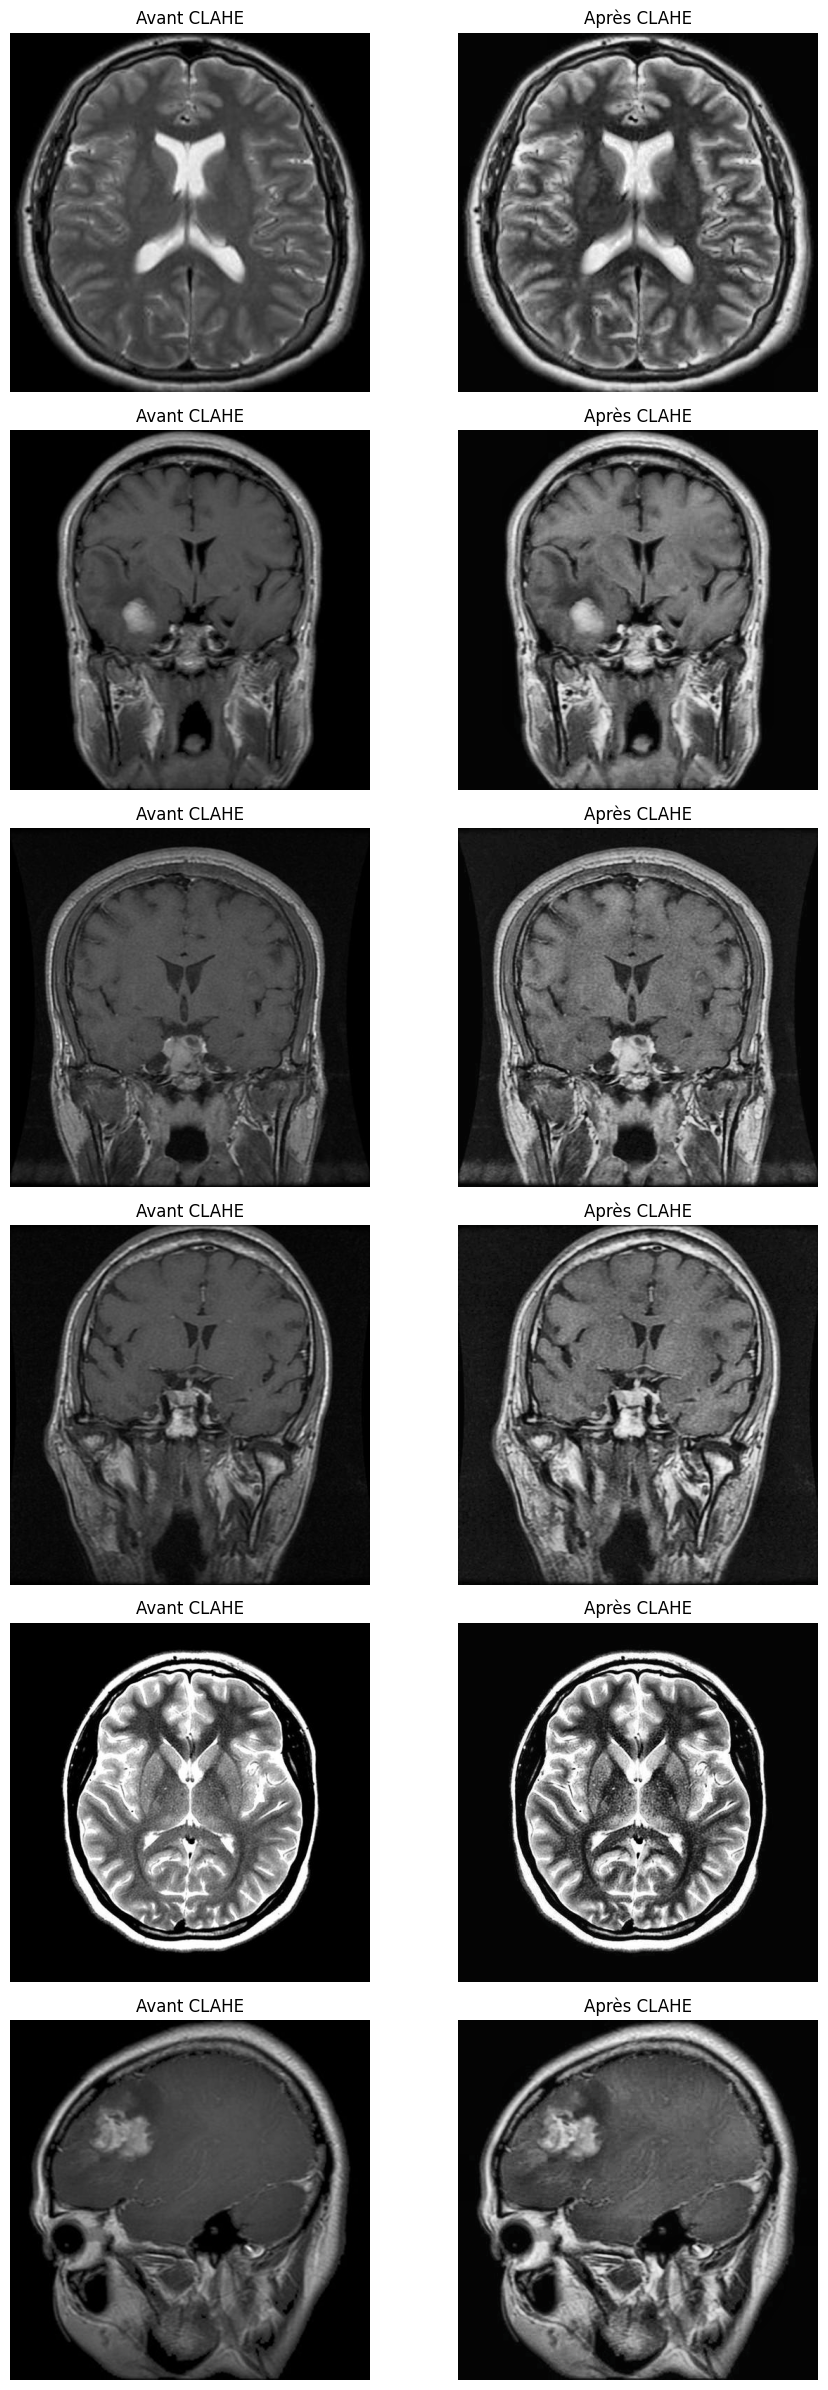

In [29]:
# =============================================================================
# 2.4 — Vérification visuelle du prétraitement CLAHE
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

sample_paths = analysis_df["path"].sample(
    n=6,
    random_state=42
).tolist()

fig, axes = plt.subplots(
    6, 2,
    figsize=(10, 24)
)

for row_idx, image_path in enumerate(sample_paths):

    # Lecture de l'image
    image = Image.open(image_path).convert("RGB")
    image_rgb = np.array(image)

    # Application de CLAHE
    image_clahe = apply_clahe(image_rgb)

    # Image originale
    axes[row_idx, 0].imshow(image_rgb)
    axes[row_idx, 0].set_title("Avant CLAHE")
    axes[row_idx, 0].axis("off")

    # Image après CLAHE
    axes[row_idx, 1].imshow(image_clahe)
    axes[row_idx, 1].set_title("Après CLAHE")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

L’analyse de la distribution des intensités montre une forte concentration des niveaux de gris vers les faibles intensités. L’application de CLAHE sur le canal de luminance améliore la répartition des intensités et le contraste local. L’analyse comparative avant/après ne met pas en évidence de saturation excessive. L’inspection visuelle confirme une meilleure netteté et une meilleure lisibilité des structures, avec moins de bruit apparent.

**CLAHE est donc retenu comme prétraitement visuel pour la suite du pipeline.**

Le paramétrage retenu est `clipLimit=2.0` et `tileGridSize=(8, 8)`.

In [30]:
# Chargement du modèle pré-entraîné


import torch
import torchvision

from torchvision.models import resnet50, ResNet50_Weights


# Vérification de l'environnement


print("PyTorch :", torch.__version__)
print("Torchvision :", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("!!GPU CUDA non disponible!!")

# Chargement des poids pré-entraînés


weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)


# Gel des paramètres

for parameter in model.parameters():
    parameter.requires_grad = False

# Mode évaluation
model.eval()

# Envoi du modèle sur le device
model = model.to(device)


# Vérification


trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print()
print("Modèle :", model.__class__.__name__)
print(f"Nombre total de paramètres : {total_parameters:,}")
print(f"Nombre de paramètres entraînables : {trainable_parameters:,}")

PyTorch : 2.9.1+cu128
Torchvision : 0.24.1+cu128
Device utilisé : cuda
GPU : NVIDIA GeForce RTX 5060 Ti

Modèle : ResNet
Nombre total de paramètres : 25,557,032
Nombre de paramètres entraînables : 0


In [31]:
# Transformations adaptées à ResNet-50


# Les transformations sont directement fournies avec les poids pré-entraînés sélectionnés pour ResNet-50.
transform = weights.transforms()

print("Transformations utilisées par ResNet-50")
print("=" * 55)
print(transform)

Transformations utilisées par ResNet-50
ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [32]:
# =============================================================================
# 2.5 — Test du pipeline complet avec CLAHE
# =============================================================================

# Transformation ResNet pré-entraînée
transform = weights.transforms()


def preprocess_image(image):
    """
    Applique le prétraitement visuel CLAHE puis
    la transformation attendue par ResNet-50.
    """

    # Conversion PIL -> RGB numpy
    image_rgb = np.array(image.convert("RGB"))

    # Amélioration du contraste avec CLAHE
    image_clahe = apply_clahe(image_rgb)

    # Conversion numpy -> PIL pour utiliser le transform ResNet
    image_clahe_pil = Image.fromarray(image_clahe)

    # Prétraitement attendu par ResNet-50
    image_tensor = transform(image_clahe_pil)

    return image_tensor

In [33]:
# Test du pipeline complet : CLAHE + preprocessing ResNet-50

test_image_path = labeled_unique_df.iloc[0]["path"]

print("Image sélectionnée :")
print(test_image_path)

with Image.open(test_image_path) as image:
    processed_tensor = preprocess_image(image)

print()
print("Caractéristiques après CLAHE + preprocessing ResNet-50")
print("=" * 55)
print("Type :", type(processed_tensor))
print("Shape :", processed_tensor.shape)
print("Dtype :", processed_tensor.dtype)
print("Device :", processed_tensor.device)

print()
print("Valeur minimale :", processed_tensor.min().item())
print("Valeur maximale :", processed_tensor.max().item())

assert processed_tensor.shape == (3, 224, 224)
assert processed_tensor.dtype == torch.float32
assert not torch.isnan(processed_tensor).any()
assert not torch.isinf(processed_tensor).any()

print()
print("✓ Pipeline CLAHE + ResNet-50 validé.")

Image sélectionnée :
/mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg

Caractéristiques après CLAHE + preprocessing ResNet-50
Type : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32
Device : cpu

Valeur minimale : -2.0665297508239746
Valeur maximale : 2.552854299545288

✓ Pipeline CLAHE + ResNet-50 validé.


In [90]:
# Test du preprocessing sur une image

"""
from PIL import Image

# Sélection d'une image de test


test_image_path = labeled_unique_df.iloc[0]["path"]

print("Image sélectionnée :")
print(test_image_path)

# Chargement de l'image


image = Image.open(test_image_path)

print()
print("Caractéristiques de l'image originale")
print("=" * 55)
print("Format :", image.format)
print("Mode   :", image.mode)
print("Taille :", image.size)


# Application des transformations ResNet-50


image_tensor = transform(image)

print()
print("Caractéristiques après preprocessing")
print("=" * 55)
print("Type :", type(image_tensor))
print("Shape :", image_tensor.shape)
print("Dtype :", image_tensor.dtype)
print("Device :", image_tensor.device)

print()
print("Valeur minimale :", image_tensor.min().item())
print("Valeur maximale :", image_tensor.max().item())
"""

Image sélectionnée :
/mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg

Caractéristiques de l'image originale
Format : JPEG
Mode   : RGB
Taille : (512, 512)

Caractéristiques après preprocessing
Type : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32
Device : cpu

Valeur minimale : -2.1179039478302
Valeur maximale : 2.4134206771850586


In [34]:
# Test d'extraction d'un embedding avec ResNet-50


import torch.nn as nn


# Création de l'extracteur de features


# On retire la dernière couche de classification de ResNet-50.
# Le réseau conserve ainsi les couches convolutionnelles et produit une représentation visuelle de dimension 2048.

feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

# Le modèle reste gelé et en mode évaluation.
feature_extractor.eval()


# Préparation de l'image

#input_tensor = image_tensor.unsqueeze(0).to(device)
input_tensor = processed_tensor.unsqueeze(0).to(device)

print("Shape de l'entrée du modèle :", input_tensor.shape)


# Extraction de l'embedding


with torch.no_grad():
    embedding = feature_extractor(input_tensor)

print()
print("Sortie brute de ResNet-50")
print("=" * 55)
print("Shape :", embedding.shape)

# Aplatissement du tenseur

embedding = embedding.flatten(start_dim=1)

print()
print("Embedding final")
print("=" * 55)
print("Shape :", embedding.shape)
print("Dtype :", embedding.dtype)
print("Device :", embedding.device)
print("Nombre de features :", embedding.shape[1])

print()
print("Valeur minimale :", embedding.min().item())
print("Valeur maximale :", embedding.max().item())

Shape de l'entrée du modèle : torch.Size([1, 3, 224, 224])

Sortie brute de ResNet-50
Shape : torch.Size([1, 2048, 1, 1])

Embedding final
Shape : torch.Size([1, 2048])
Dtype : torch.float32
Device : cuda:0
Nombre de features : 2048

Valeur minimale : 0.0
Valeur maximale : 4.724784851074219


- Ce résultat montre qu'une image prétraitée peut être transformée par ResNet-50 en un embedding numérique de dimension 2048, calculé sur GPU.
- Ces embeddings doivent maintenant être produits pour l'ensemble du jeu de données analytiques et être sauvegardés dans un tableau exploitable.

In [35]:
# Contrôle du gel de l'extracteur et préparation/test du DataLoader

from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Vérification que l'extracteur est bien gelé


trainable_parameters = sum(
    parameter.numel()
    for parameter in feature_extractor.parameters()
    if parameter.requires_grad
)

print("Vérification de l'extracteur")
print("=" * 55)
print(f"Paramètres entraînables : {trainable_parameters:,}")

assert trainable_parameters == 0, (
    "Erreur : certains paramètres de l'extracteur sont entraînables."
)

print("Tous les paramètres de l'extracteur sont gelés.")

# Vérification du device
extractor_device = next(feature_extractor.parameters()).device
print(f"Device de l'extracteur : {extractor_device}")


# Préparation du DataFrame utilisé pour l'extraction


# Images fortement labellisées uniques
labeled_features_df = labeled_unique_df.copy()
labeled_features_df["subset"] = "labeled"

# Images sans label uniques
unlabeled_features_df = unlabeled_unique_df.copy()
unlabeled_features_df["subset"] = "unlabeled"

# Fusion des deux sous-ensembles
features_input_df = pd.concat(
    [
        labeled_features_df,
        unlabeled_features_df
    ],
    ignore_index=True
)

print()
print("Jeu de données préparé pour l'extraction")
print("=" * 55)
print(f"Nombre total d'images : {len(features_input_df)}")
print(
    features_input_df["subset"]
    .value_counts()
)


# Dataset PyTorch

class BrainImageDataset(Dataset):

    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Chargement de l'image
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

        # Prétraitement visuel CLAHE
        # puis transformations adaptées à ResNet-50
        image_tensor = preprocess_image(image)

        return image_tensor, index


# Création du DataLoader

feature_dataset = BrainImageDataset(
    dataframe=features_input_df,
    transform=transform
)

feature_loader = DataLoader(
    feature_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print()
print("DataLoader")
print("=" * 55)
print(f"Taille du dataset : {len(feature_dataset)}")
print(f"Taille des batches : {feature_loader.batch_size}")
print(f"Nombre de batches : {len(feature_loader)}")


# Test d'un batch


batch_images, batch_indices = next(iter(feature_loader))

print()
print("Test du premier batch")
print("=" * 55)
print("Images :", batch_images.shape)
print("Dtype  :", batch_images.dtype)
print("Indices:", batch_indices[:10].tolist())

assert batch_images.shape[1:] == (3, 224, 224)
assert batch_images.dtype == torch.float32

print()
print("DataLoader opérationnel.")
print("Les images sont prêtes pour l'extraction des embeddings.")

Vérification de l'extracteur
Paramètres entraînables : 0
Tous les paramètres de l'extracteur sont gelés.
Device de l'extracteur : cuda:0

Jeu de données préparé pour l'extraction
Nombre total d'images : 1410
subset
unlabeled    1311
labeled        99
Name: count, dtype: int64

DataLoader
Taille du dataset : 1410
Taille des batches : 32
Nombre de batches : 45

Test du premier batch
Images : torch.Size([32, 3, 224, 224])
Dtype  : torch.float32
Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

DataLoader opérationnel.
Les images sont prêtes pour l'extraction des embeddings.


In [36]:
# Extraction des embeddings ResNet-50


import numpy as np
import time

# Initialisation


all_embeddings = []
all_indices = []

start_time = time.time()


# Extraction batch par batch


feature_extractor.eval()

with torch.no_grad():

    for batch_number, (batch_images, batch_indices) in enumerate(
        feature_loader,
        start=1
    ):

        # Envoi des images sur le GPU
        batch_images = batch_images.to(device, non_blocking=True)

        # Extraction des features
        batch_features = feature_extractor(batch_images)

        # Passage de [batch, 2048, 1, 1] à [batch, 2048]
        batch_features = batch_features.flatten(start_dim=1)

        # Retour CPU pour libérer progressivement la VRAM
        all_embeddings.append(
            batch_features.cpu().numpy()
        )

        all_indices.append(
            batch_indices.numpy()
        )

        # Affichage de la progression
        if batch_number == 1 or batch_number % 10 == 0:
            print(
                f"Batch {batch_number:02d}/{len(feature_loader)} "
                f"| Images traitées : "
                f"{batch_number * feature_loader.batch_size}"
            )


# Assemblage des résultats


embeddings = np.concatenate(
    all_embeddings,
    axis=0
)

embedding_indices = np.concatenate(
    all_indices,
    axis=0
)

elapsed_time = time.time() - start_time


# Vérifications


print()
print("Extraction terminée")
print("=" * 55)

print(f"Nombre d'images traitées : {len(embeddings)}")
print(f"Dimension des embeddings : {embeddings.shape[1]}")
print(f"Shape finale              : {embeddings.shape}")
print(f"Temps d'extraction        : {elapsed_time:.2f} secondes")

print()
print("Type :", embeddings.dtype)
print("NaN :", np.isnan(embeddings).sum())
print("Inf :", np.isinf(embeddings).sum())

# Vérification de la correspondance avec le dataset
assert embeddings.shape == (len(features_input_df), 2048)
assert len(embedding_indices) == len(features_input_df)
assert np.array_equal(
    embedding_indices,
    np.arange(len(features_input_df))
)

assert not np.isnan(embeddings).any()
assert not np.isinf(embeddings).any()

print()
print("1 410 embeddings extraits.")
print("Dimension : 2048 features par image.")
print("Aucun NaN ou Inf détecté.")
print("Correspondance image ↔ embedding vérifiée.")

Batch 01/45 | Images traitées : 32
Batch 10/45 | Images traitées : 320
Batch 20/45 | Images traitées : 640
Batch 30/45 | Images traitées : 960
Batch 40/45 | Images traitées : 1280

Extraction terminée
Nombre d'images traitées : 1410
Dimension des embeddings : 2048
Shape finale              : (1410, 2048)
Temps d'extraction        : 5.32 secondes

Type : float32
NaN : 0
Inf : 0

1 410 embeddings extraits.
Dimension : 2048 features par image.
Aucun NaN ou Inf détecté.
Correspondance image ↔ embedding vérifiée.


In [37]:
# Construction de la table des embeddings

# Création des noms de features


embedding_columns = [
    f"feature_{i:04d}"
    for i in range(embeddings.shape[1])
]


# Création du DataFrame des embeddings


embeddings_df = pd.DataFrame(
    embeddings,
    columns=embedding_columns
)


# Conservation des métadonnées


metadata_columns = [
    "label",
    "subset",
    "filename",
    "path",
    "md5"
]

embeddings_df = pd.concat(
    [
        features_input_df[metadata_columns].reset_index(drop=True),
        embeddings_df
    ],
    axis=1
)


# Vérifications


print("Table des embeddings")
print("=" * 55)

print("Nombre de lignes :", len(embeddings_df))
print("Nombre de colonnes :", len(embeddings_df.columns))

print()
print("Répartition des sous-ensembles :")
print(embeddings_df["subset"].value_counts())

print()
print("Répartition des labels :")
print(embeddings_df["label"].value_counts())

print()
print("Aperçu :")
display(embeddings_df.iloc[:, :10].head())

# Vérifications structurelles
assert len(embeddings_df) == 1410
assert len(embedding_columns) == 2048
assert embeddings_df.shape[1] == 2049 + len(metadata_columns) - 1

print()
print("Table des embeddings construite.")
print("Métadonnées conservées.")
print("2 048 features disponibles par image.")

# Vérification de l'absence de valeurs invalides
feature_values = embeddings_df[embedding_columns].to_numpy()

assert not np.isnan(feature_values).any()
assert not np.isinf(feature_values).any()

print()
print("Vérification des valeurs des embeddings")
print("=" * 55)
print("NaN :", np.isnan(feature_values).sum())
print("Inf :", np.isinf(feature_values).sum())

print()
print("✓ Table des embeddings CLAHE construite et validée.")

Table des embeddings
Nombre de lignes : 1410
Nombre de colonnes : 2053

Répartition des sous-ensembles :
subset
unlabeled    1311
labeled        99
Name: count, dtype: int64

Répartition des labels :
label
sans_label    1311
cancer          50
normal          49
Name: count, dtype: int64

Aperçu :


,label,subset,filename,path,md5,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004
0,cancer,labeled,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,82feb195cc989de29f0d584705afd746,0.032043,0.101104,0.336776,0.104018,0.214914
1,cancer,labeled,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,1fe2130e1834ff8646f635f6a6f86dc1,0.000000,0.004614,0.000000,0.000000,0.000000
2,cancer,labeled,0f718241-8f63-4b55-81ce-315324b51069.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,32debb468cdfa4c513e648c61f8349f8,0.045860,0.067016,0.152513,0.000000,0.000000
3,cancer,labeled,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,bf80e340a7b4fcf553202847221bfe1f,0.039345,0.000000,0.069571,0.000000,0.000000
4,cancer,labeled,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,d642b0a782a25dee640a9b76a2f55112,0.004060,0.041712,0.103741,0.000000,0.004078



Table des embeddings construite.
Métadonnées conservées.
2 048 features disponibles par image.

Vérification des valeurs des embeddings
NaN : 0
Inf : 0

✓ Table des embeddings CLAHE construite et validée.


In [38]:
# Vérification structurelle finale

expected_metadata_columns = 5
expected_feature_columns = 2048
expected_total_columns = (
    expected_metadata_columns + expected_feature_columns
)

print("Vérification finale de la table des embeddings")
print("=" * 55)

print(f"Colonnes de métadonnées attendues : {expected_metadata_columns}")
print(f"Features attendues                : {expected_feature_columns}")
print(f"Colonnes totales attendues        : {expected_total_columns}")
print(f"Colonnes réellement présentes     : {embeddings_df.shape[1]}")

assert embeddings_df.shape[1] == expected_total_columns
assert embeddings_df[embedding_columns].shape == (1410, 2048)
assert embeddings_df["path"].notna().all()
assert embeddings_df["md5"].notna().all()

print()
print("Structure de la table validée.")
print("5 métadonnées + 2 048 features.")
print("Aucune métadonnée manquante.")

Vérification finale de la table des embeddings
Colonnes de métadonnées attendues : 5
Features attendues                : 2048
Colonnes totales attendues        : 2053
Colonnes réellement présentes     : 2053

Structure de la table validée.
5 métadonnées + 2 048 features.
Aucune métadonnée manquante.


In [39]:
# Contrôle présence bibliothèque pyarrow

import sys
import pyarrow

print("Python :", sys.executable)
print("PyArrow :", pyarrow.__version__)

Python : /mnt/projects/envs/dl-pytorch/bin/python
PyArrow : 25.0.1


In [40]:
# Sauvegarde et vérification des embeddings


from pathlib import Path


# Définition du chemin de sortie


PROCESSED_DIR = (
    Path("/mnt/projects/vk_oc_projet10_brainscanai")
    / "data/processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EMBEDDINGS_CSV_PATH = (
    PROCESSED_DIR / "embeddings_resnet50.csv"
)


# Sauvegarde au format CSV


embeddings_df.to_csv(
    EMBEDDINGS_CSV_PATH,
    index=False
)


# Vérification du fichier


print("Sauvegarde des embeddings")
print("=" * 55)

print("Fichier :", EMBEDDINGS_CSV_PATH)
print(
    "Taille :",
    f"{EMBEDDINGS_CSV_PATH.stat().st_size / (1024**2):.2f} MB"
)

assert EMBEDDINGS_CSV_PATH.exists()
assert EMBEDDINGS_CSV_PATH.stat().st_size > 0


# Test de relecture


embeddings_check_df = pd.read_csv(
    EMBEDDINGS_CSV_PATH
)

print()
print("Vérification après relecture")
print("=" * 55)

print("Shape originale :", embeddings_df.shape)
print("Shape relue     :", embeddings_check_df.shape)

# Vérification de la structure
assert embeddings_check_df.shape == embeddings_df.shape

# Vérification des colonnes
assert list(embeddings_check_df.columns) == list(
    embeddings_df.columns
)

# Vérification des features
reloaded_embeddings = embeddings_check_df[
    embedding_columns
].to_numpy(dtype=np.float32)

assert reloaded_embeddings.shape == embeddings.shape

assert np.allclose(
    reloaded_embeddings,
    embeddings,
    rtol=1e-5,
    atol=1e-6
)

print()
print("CSV sauvegardé.")
print("CSV relu correctement.")
print("Shape identique.")
print("Colonnes identiques.")
print("Embeddings conservés sans différence significative.")

Sauvegarde des embeddings
Fichier : /mnt/projects/vk_oc_projet10_brainscanai/data/processed/embeddings_resnet50.csv
Taille : 21.89 MB

Vérification après relecture
Shape originale : (1410, 2053)
Shape relue     : (1410, 2053)

CSV sauvegardé.
CSV relu correctement.
Shape identique.
Colonnes identiques.
Embeddings conservés sans différence significative.


- Le format CSV a été retenu pour assurer la lisibilité et la traçabilité des embeddings dans le cadre du prototype.
- Une solution de stockage colonne ou binaire pourrait être privilégiée dans une industrialisation à plus grande échelle.

In [41]:
# Vérification visuelle du fichier CSV des embeddings


# Relecture du fichier sauvegardé
embeddings_saved_df = pd.read_csv(
    EMBEDDINGS_CSV_PATH
)

print("Extrait du fichier CSV des embeddings")
print("=" * 70)

print(
    f"Dimensions du fichier : {embeddings_saved_df.shape}"
)

print()
print("Premières lignes et premières features :")
print()

display(
    embeddings_saved_df[
        [
            "label",
            "subset",
            "filename",
            "path",
            "md5",
            "feature_0000",
            "feature_0001",
            "feature_0002",
            "feature_0003",
            "feature_0004",
        ]
    ].head()
)

print()
print("Quelques colonnes de features supplémentaires :")
print()

display(
    embeddings_saved_df[
        [
            "feature_0000",
            "feature_0001",
            "feature_0002",
            "feature_0003",
            "feature_1023",
            "feature_1024",
            "feature_2046",
            "feature_2047",
        ]
    ].head()
)

# Vérification finale


assert embeddings_saved_df.shape == (1410, 2053)

assert all(
    column in embeddings_saved_df.columns
    for column in [
        "feature_0000",
        "feature_0001",
        "feature_1024",
        "feature_2047",
    ]
)

assert (
    embeddings_saved_df[
        embedding_columns
    ].notna().all().all()
)

print("Le fichier CSV contient bien les 2 048 features.")
print("Les embeddings sont effectivement sauvegardés.")
print("Les métadonnées sont conservées.")

Extrait du fichier CSV des embeddings
Dimensions du fichier : (1410, 2053)

Premières lignes et premières features :



,label,subset,filename,path,md5,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004
0,cancer,labeled,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,82feb195cc989de29f0d584705afd746,0.032043,0.101104,0.336776,0.104018,0.214914
1,cancer,labeled,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,1fe2130e1834ff8646f635f6a6f86dc1,0.000000,0.004614,0.000000,0.000000,0.000000
2,cancer,labeled,0f718241-8f63-4b55-81ce-315324b51069.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,32debb468cdfa4c513e648c61f8349f8,0.045860,0.067016,0.152513,0.000000,0.000000
3,cancer,labeled,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,bf80e340a7b4fcf553202847221bfe1f,0.039345,0.000000,0.069571,0.000000,0.000000
4,cancer,labeled,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,d642b0a782a25dee640a9b76a2f55112,0.004060,0.041712,0.103742,0.000000,0.004078



Quelques colonnes de features supplémentaires :



,feature_0000,feature_0001,feature_0002,feature_0003,feature_1023,feature_1024,feature_2046,feature_2047
0,0.032043,0.101104,0.336776,0.104018,0.0,0.323846,0.029689,0.537379
1,0.000000,0.004614,0.000000,0.000000,0.0,0.045184,0.000000,0.000000
2,0.045860,0.067016,0.152513,0.000000,0.0,0.062655,0.004119,0.002794
3,0.039345,0.000000,0.069571,0.000000,0.0,0.064348,0.109901,0.000000
4,0.004060,0.041712,0.103742,0.000000,0.0,0.008732,0.003384,0.226803


Le fichier CSV contient bien les 2 048 features.
Les embeddings sont effectivement sauvegardés.
Les métadonnées sont conservées.


# Synthèse de l'Étape 2 — Prétraitement et extraction des features

## 2A. Objectif

Cette étape avait pour objectif de transformer les images cérébrales en représentations numériques exploitables pour l'analyse non supervisée et la classification semi-supervisée.

Le pipeline mis en place est :

**Image → Prétraitement → ResNet-50 pré-entraîné → Embedding de 2 048 dimensions**



## 2B. Préparation des données

L'extraction des features a été réalisée sur les jeux analytiques construits lors de l'Étape 1 :

- **99 images fortement labellisées uniques**
  - 50 `cancer`
  - 49 `normal` après déduplication exacte
- **1 311 images sans label uniques**

Les doublons exacts et les copies d'images labellisées présentes dans le jeu sans label ont été exclus des jeux analytiques afin de limiter les risques de biais et de fuite d'information lors des analyses ultérieures.

Aucun fichier source n'a été supprimé : les exclusions concernent uniquement les jeux de données utilisés pour l'analyse.



## 2C. Prétraitement des images

Le preprocessing fourni avec les poids pré-entraînés de **ResNet-50** a été utilisé afin de garantir la compatibilité entre les images et le modèle.

Les transformations appliquées sont :

- redimensionnement à une taille de 232 × 232 pixels ;
- recadrage central à 224 × 224 pixels ;
- conversion en tenseur ;
- normalisation selon les statistiques ImageNet ;
- traitement en trois canaux RGB.

Ce choix constitue un preprocessing standard et reproductible pour l'utilisation d'un ResNet-50 pré-entraîné sur ImageNet.



## 2D. Extraction des représentations visuelles

Un **ResNet-50 pré-entraîné sur ImageNet** a été utilisé comme extracteur de caractéristiques.

Les paramètres du réseau ont été gelés et aucune phase d'apprentissage n'a été réalisée à cette étape.

La couche de classification finale a été retirée afin de conserver la représentation produite par le réseau après le Global Average Pooling.

Chaque image est ainsi représentée par un vecteur de :

**2 048 caractéristiques numériques.**

L'extraction a été réalisée sur GPU lorsque celui-ci était disponible.



## 2E. Contrôles de qualité des embeddings

L'extraction a produit :

- **1 410 images traitées** ;
- **1 410 embeddings** ;
- **2 048 features par embedding** ;
- une matrice finale de taille **(1 410, 2 048)**.

Les contrôles réalisés ont confirmé :

- aucune valeur `NaN` ;
- aucune valeur infinie (`Inf`) ;
- aucune perte d'image pendant l'extraction ;
- une correspondance correcte entre chaque image et son embedding ;
- une structure de données cohérente avec les métadonnées associées.



## 2F. Persistance des résultats

Les embeddings ont été sauvegardés dans :

`data/processed/embeddings_resnet50.csv`

Le fichier contient :

- les métadonnées associées aux images ;
- les 2 048 features extraites par ResNet-50.

La relecture du fichier a été vérifiée avec succès :

- shape originale : **(1 410, 2 053)** ;
- shape après relecture : **(1 410, 2 053)** ;
- colonnes identiques ;
- embeddings conservés sans différence significative.

Le format CSV est retenu comme format de référence pour cette étude exploratoire afin de garantir une solution simple, transparente et reproductible.



## 2G. Justification méthodologique

L'utilisation d'un modèle pré-entraîné permet d'exploiter des représentations visuelles riches sans disposer d'un volume important d'images annotées pour entraîner un réseau de neurones complet depuis zéro.

Cette approche est particulièrement adaptée au contexte du projet, qui dispose d'un nombre limité d'images fortement labellisées et d'un ensemble beaucoup plus important d'images sans label.

Les embeddings obtenus constituent maintenant l'espace de représentation qui sera utilisé pour l'analyse non supervisée.



## 2H. Conclusion de l'Étape 2

L'étape de préparation et d'extraction des features est validée.

Le jeu de données dispose désormais d'une représentation numérique exploitable pour l'étape suivante :

**1 410 images → 2 048 caractéristiques par image**

La prochaine étape consiste à étudier la **distribution des embeddings**, puis à standardiser les caractéristiques et à appliquer une réduction dimensionnelle avant les algorithmes de clustering.

> **Limitation méthodologique :** les représentations utilisées proviennent d'un modèle pré-entraîné sur ImageNet et non spécifiquement sur l'imagerie médicale. Cette approche est adaptée à une étude exploratoire de faisabilité, mais ses performances devront être évaluées avant toute utilisation dans un contexte clinique.

# Étape 3 — Réaliser une analyse non supervisée

## 3.1 — Analyse des biais potentiels et des observations atypiques

In [42]:
# =============================================================================
# 3.1 — Analyse des caractéristiques d'image
# =============================================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


image_statistics = []

for path in features_input_df["path"]:

    image_gray = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image_gray is None:
        raise ValueError(f"Impossible de lire l'image : {path}")

    image_statistics.append({
        "path": str(path),
        "mean_intensity": float(image_gray.mean()),
        "std_intensity": float(image_gray.std()),
        "min_intensity": int(image_gray.min()),
        "max_intensity": int(image_gray.max()),
        "dark_ratio": float(
            (image_gray < 32).mean()
        ),
        "bright_ratio": float(
            (image_gray >= 224).mean()
        )
    })


image_stats_df = pd.DataFrame(image_statistics)

# Rattachement des métadonnées
image_stats_df = image_stats_df.merge(
    features_input_df[
        ["path", "label", "subset", "filename"]
    ],
    on="path",
    how="left"
)

print("Analyse des caractéristiques des images")
print("=" * 60)

print("Nombre d'images :", len(image_stats_df))

display(
    image_stats_df[
        [
            "mean_intensity",
            "std_intensity",
            "min_intensity",
            "max_intensity",
            "dark_ratio",
            "bright_ratio"
        ]
    ].describe()
)

Analyse des caractéristiques des images
Nombre d'images : 1410


,mean_intensity,std_intensity,min_intensity,max_intensity,dark_ratio,bright_ratio
count,1410.000000,1410.000000,1410.000000,1410.000000,1410.000000,1410.000000
mean,51.767515,48.271716,0.054610,252.093617,0.440287,0.009866
std,16.969010,13.288152,0.929294,9.433554,0.111697,0.025603
min,14.945938,20.893025,0.000000,126.000000,0.001610,0.000000
25%,41.038524,39.629080,0.000000,253.000000,0.360021,0.000122
50%,49.910868,44.657346,0.000000,255.000000,0.423059,0.000631
75%,58.375915,52.850642,0.000000,255.000000,0.517400,0.003203
max,136.216469,119.179042,25.000000,255.000000,0.786228,0.402927


In [43]:
# Comparaison des caractéristiques selon le sous-ensemble

# Normalisation du type des chemins avant fusion
image_stats_df["path"] = image_stats_df["path"].astype(str)
features_input_df["path"] = features_input_df["path"].astype(str)

# Récupération des métadonnées associées aux images
image_stats_df = image_stats_df.drop(
    columns=["label", "subset", "filename"],
    errors="ignore"
)

image_stats_df = image_stats_df.merge(
    features_input_df[["path", "label", "subset", "filename"]],
    on="path",
    how="left",
    validate="one_to_one"
)

print("Vérification après fusion")
print("=" * 60)

print("Nombre d'images :", len(image_stats_df))
print("\nValeurs de subset :")
print(image_stats_df["subset"].value_counts(dropna=False))

print("\nValeurs de label :")
print(image_stats_df["label"].value_counts(dropna=False))

print("\nValeurs manquantes :")
print(image_stats_df[["subset", "label", "filename"]].isna().sum())

Vérification après fusion
Nombre d'images : 1410

Valeurs de subset :
subset
unlabeled    1311
labeled        99
Name: count, dtype: int64

Valeurs de label :
label
sans_label    1311
cancer          50
normal          49
Name: count, dtype: int64

Valeurs manquantes :
subset      0
label       0
filename    0
dtype: int64


In [44]:
print("Vérification des colonnes de regroupement")
print("=" * 60)

print("Valeurs de subset :")
print(image_stats_df["subset"].value_counts(dropna=False))

print("\nValeurs de label :")
print(image_stats_df["label"].value_counts(dropna=False))

print("\nNombre de valeurs manquantes :")
print(image_stats_df[["subset", "label"]].isna().sum())

Vérification des colonnes de regroupement
Valeurs de subset :
subset
unlabeled    1311
labeled        99
Name: count, dtype: int64

Valeurs de label :
label
sans_label    1311
cancer          50
normal          49
Name: count, dtype: int64

Nombre de valeurs manquantes :
subset    0
label     0
dtype: int64


In [45]:
print("Diagnostic des chemins")
print("=" * 70)

print("Type image_stats_df['path'] :", image_stats_df["path"].dtype)
print("Type features_input_df['path'] :", features_input_df["path"].dtype)

print("\nExemple image_stats_df :")
print(image_stats_df["path"].iloc[0])

print("\nExemple features_input_df :")
print(features_input_df["path"].iloc[0])

print("\nCorrespondance exacte du premier chemin :")
print(
    image_stats_df["path"].iloc[0]
    == str(features_input_df["path"].iloc[0])
)

print("\nColonnes disponibles dans features_input_df :")
print(features_input_df.columns.tolist())

Diagnostic des chemins
Type image_stats_df['path'] : str
Type features_input_df['path'] : str

Exemple image_stats_df :
/mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg

Exemple features_input_df :
/mnt/projects/vk_oc_projet10_brainscanai/data/raw/dataset_original/dataset_extracted/mri_dataset_brain_cancer_oc/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg

Correspondance exacte du premier chemin :
True

Colonnes disponibles dans features_input_df :
['label', 'filename', 'path', 'md5', 'subset']


In [46]:
# Comparaison des caractéristiques selon le sous-ensemble

print("Caractéristiques selon le sous-ensemble")
print("=" * 60)

subset_stats = (
    image_stats_df
    .groupby("subset")[
        [
            "mean_intensity",
            "std_intensity",
            "dark_ratio",
            "bright_ratio"
        ]
    ]
    .agg(["mean", "median", "std"])
)

display(subset_stats)

Caractéristiques selon le sous-ensemble


mean_intensity                       std_intensity             \
                    mean     median        std          mean     median   
subset                                                                    
labeled        53.926531  51.691601  21.474067     52.755535  48.663774   
unlabeled      51.604478  49.864220  16.578063     47.933121  44.534131   

                     dark_ratio                     bright_ratio            \
                 std       mean    median       std         mean    median   
subset                                                                       
labeled    16.316099   0.480801  0.471882  0.117217     0.018306  0.002060   
unlabeled  12.975739   0.437227  0.419849  0.110715     0.009228  0.000599   

                     
                std  
subset               
labeled    0.031123  
unlabeled  0.025036

### Comparaison `labeled` / `unlabeled`

| Caractéristique | Labeled | Unlabeled | Lecture |
|---|---:|---:|---|
| Intensité moyenne | 53,93 | 51,60 | légèrement plus élevée chez labeled |
| Intensité médiane | 51,69 | 49,86 | proche |
| Écart-type intensité | 52,76 | 47,93 | contraste un peu plus élevé chez labeled |
| Dark ratio | 48,08 % | 43,72 % | davantage de pixels sombres chez labeled |
| Bright ratio | 1,83 % | 0,92 % | davantage de pixels très clairs chez labeled |

### 2. Ce que cela signifie

Il existe **une différence de distribution entre les deux sous-ensembles**, mais elle ne paraît pas suffisamment importante pour conclure à un biais majeur sur cette seule analyse.

Le signal le plus intéressant est le `bright_ratio` :

> Les images labellisées ont en moyenne environ **1,83 %** de pixels ≥ 224, contre **0,92 %** pour les images non labellisées.

Le contraste est également un peu plus élevé dans le groupe labellisé.

Cela suggère que les images labellisées ne sont **pas parfaitement représentatives** des images non labellisées sur le plan de l'intensité. C'est important à documenter, particulièrement parce que les **99 images labellisées** sont celles qui serviront à construire et à évaluer la supervision.

Cependant, **on ne doit pas supprimer les images `labeled` pour cette raison**.

> **Interprétation — biais potentiels**
>
> La comparaison des caractéristiques d'intensité met en évidence des différences modérées entre les images labellisées et non labellisées. Les images labellisées présentent en moyenne une intensité et une dispersion légèrement supérieures, ainsi qu'une proportion plus importante de pixels très clairs. Ces différences suggèrent une hétérogénéité de distribution entre les deux sous-ensembles, mais ne suffisent pas à justifier l'exclusion d'images. Une normalisation du contraste par CLAHE a donc été retenue afin de réduire l'influence des variations d'éclairage et de contraste avant l'extraction des représentations visuelles.

**Important :** CLAHE ne supprime pas le biais. Il **réduit l'influence des variations de contraste et d'intensité**.

In [47]:
# Identification des observations potentiellement atypiques

print("Observations potentiellement atypiques")
print("=" * 70)

print("\nImages avec les plus fortes intensités moyennes")
print("-" * 70)

display(
    image_stats_df[
        [
            "filename",
            "subset",
            "label",
            "mean_intensity",
            "std_intensity",
            "dark_ratio",
            "bright_ratio"
        ]
    ]
    .sort_values("mean_intensity", ascending=False)
    .head(10)
)

print("\nImages avec la plus forte proportion de pixels clairs")
print("-" * 70)

display(
    image_stats_df[
        [
            "filename",
            "subset",
            "label",
            "mean_intensity",
            "std_intensity",
            "dark_ratio",
            "bright_ratio"
        ]
    ]
    .sort_values("bright_ratio", ascending=False)
    .head(10)
)

Observations potentiellement atypiques

Images avec les plus fortes intensités moyennes
----------------------------------------------------------------------


,filename,subset,label,mean_intensity,std_intensity,dark_ratio,bright_ratio
668,6b4861c4-0479-49a9-8022-4de4fd6ced6e.jpg,unlabeled,sans_label,136.216469,76.421819,0.187664,0.125027
1375,f8febf3a-54c6-443a-bb03-ae6282256f5b.jpg,unlabeled,sans_label,120.912365,57.230524,0.065250,0.057747
1132,ca4c389b-8e9b-40d0-b149-1c81934ea251.jpg,unlabeled,sans_label,116.410290,119.179042,0.479916,0.402927
1253,e31ccf86-45ab-42b1-9cb2-46f7ac5970a1.jpg,unlabeled,sans_label,115.306122,86.541566,0.334488,0.142883
76,6eb7dfc4-dd36-41cb-b5ea-f68c01aab86b.jpg,labeled,normal,115.188698,86.314978,0.334278,0.142067
916,a24e6a4f-5dca-498f-9329-1e6cfe84b131.jpg,unlabeled,sans_label,112.294094,78.062902,0.326412,0.041389
1225,dda4e1f7-3614-4903-a53f-45a9b838d785.jpg,unlabeled,sans_label,111.528004,82.361805,0.319736,0.066540
1304,ecdd85a0-adc9-4db5-acb5-23c4b010ead1.jpg,unlabeled,sans_label,111.483021,94.762049,0.365246,0.165413
689,6e7f4ce7-00f4-43be-8bbf-299d79968dcd.jpg,unlabeled,sans_label,108.673424,73.168995,0.212372,0.086411
955,aa3b5558-4655-4cc2-a6f1-b7a1183202ec.jpg,unlabeled,sans_label,107.352524,75.739342,0.282520,0.035336



Images avec la plus forte proportion de pixels clairs
----------------------------------------------------------------------


,filename,subset,label,mean_intensity,std_intensity,dark_ratio,bright_ratio
1132,ca4c389b-8e9b-40d0-b149-1c81934ea251.jpg,unlabeled,sans_label,116.410290,119.179042,0.479916,0.402927
1304,ecdd85a0-adc9-4db5-acb5-23c4b010ead1.jpg,unlabeled,sans_label,111.483021,94.762049,0.365246,0.165413
620,61e529cd-243c-41a1-aab7-ad06eb8281bf.jpg,unlabeled,sans_label,54.583954,96.497320,0.738781,0.161312
176,0d525cdf-aa38-4dd1-bc4b-df94ebdad32f.jpg,unlabeled,sans_label,103.350315,91.510034,0.360004,0.156979
703,71334459-58f0-4373-8805-6100e6d9b5ed.jpg,unlabeled,sans_label,104.803997,91.228220,0.353394,0.155273
1253,e31ccf86-45ab-42b1-9cb2-46f7ac5970a1.jpg,unlabeled,sans_label,115.306122,86.541566,0.334488,0.142883
76,6eb7dfc4-dd36-41cb-b5ea-f68c01aab86b.jpg,labeled,normal,115.188698,86.314978,0.334278,0.142067
543,55938246-aacc-4725-8e13-59d3bfaaf974.jpg,unlabeled,sans_label,91.842251,85.613542,0.370110,0.140343
726,75cd4442-21fd-4003-8937-449b302a07d1.jpg,unlabeled,sans_label,66.465473,96.411339,0.645611,0.138401
271,1e07b53a-7dff-496f-8e56-9ffbda1f3062.jpg,unlabeled,sans_label,95.737881,83.300200,0.331177,0.132793


### Ce que montrent les résultats

On observe quelques images nettement atypiques :

- `ca4c389b...` : intensité moyenne **116,4** et **40,3 % de pixels ≥ 224** → observation particulièrement extrême.
- `ecdd85a0...` : intensité moyenne **111,5** et **16,5 %** de pixels clairs.
- `6b4861c4...` : intensité moyenne **136,2**, la plus élevée.
- `61e529cd...` : `dark_ratio` de **73,9 %** mais `bright_ratio` de **16,1 %**, ce qui traduit une distribution très contrastée.
- Une image **labeled / normal** apparaît également parmi les intensités élevées (`6eb7dfc4...`).

Un point important : **la majorité des observations extrêmes viennent du jeu `unlabeled`**, mais on ne peut pas conclure qu'elles sont erronées.

### Décision méthodologique

**Conservation de ces images.**

Pourquoi ?

Parce qu'une observation atypique en intensité peut correspondre à :

- une acquisition avec un contraste différent ;
- une image médicalement valide mais avec une dynamique différente ;
- une particularité du protocole d'imagerie ;
- ou effectivement une anomalie technique.

Sans métadonnées d'acquisition ni validation experte, supprimer ces images serait difficile à justifier.

De plus, le fait qu'une image `normal` soit elle-même parmi les plus atypiques montre qu'il serait risqué d'utiliser un simple seuil d'intensité pour filtrer les données.

> **Analyse des observations atypiques**
>
> Plusieurs images présentent des caractéristiques d'intensité nettement éloignées de la distribution générale, notamment une intensité moyenne élevée, une forte dispersion des niveaux de gris ou une proportion importante de pixels très clairs. Ces observations sont principalement présentes dans le sous-ensemble non labellisé, mais une image labellisée de classe *normal* apparaît également parmi les valeurs extrêmes.
>
> En l'absence de métadonnées d'acquisition et de validation experte permettant de distinguer une anomalie technique d'une variation réelle d'imagerie, aucune image n'est supprimée sur la seule base de ces statistiques. Ces observations sont conservées afin de préserver la diversité du jeu de données. La normalisation du contraste par CLAHE vise à réduire l'influence des variations d'intensité et de contraste avant l'extraction des représentations ResNet-50.

Cette formulation est **plus solide méthodologiquement** que d'indiquer que les outliers ont été supprimés.

### Biais potentiel lié à la source des images

> Les fichiers fournis ne contiennent pas de métadonnées permettant d'identifier l'hôpital, le scanner, le constructeur, le protocole d'acquisition ou le patient. L'hétérogénéité entre les sources médicales ne peut donc pas être mesurée directement. L'analyse des distributions d'intensité constitue ici un contrôle indirect de l'homogénéité des images.

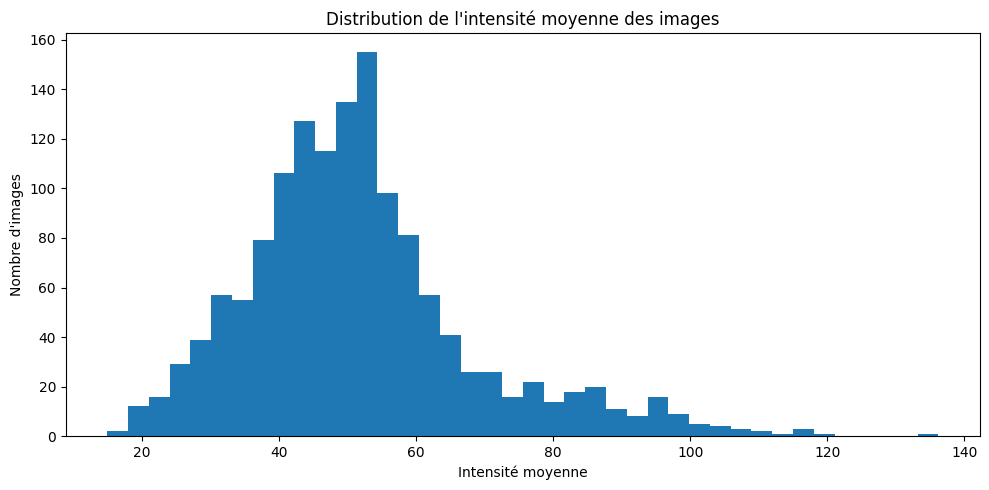

In [48]:
# Distribution de la luminosité moyenne des images

plt.figure(figsize=(10, 5))

plt.hist(
    image_stats_df["mean_intensity"],
    bins=40
)

plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.title(
    "Distribution de l'intensité moyenne des images"
)

plt.tight_layout()
plt.show()

Analyse de la distribution des embeddings
Nombre d'images      : 1410
Nombre de features   : 2048

Contrôles de qualité
----------------------------------------------------------------------
Valeurs NaN : 0
Valeurs Inf : 0

Statistiques globales
----------------------------------------------------------------------
Minimum              : 0.000000
Maximum              : 8.534242
Moyenne              : 0.092916
Écart-type           : 0.299878

Percentiles
----------------------------------------------------------------------
  0.0 % : 0.000000
 25.0 % : 0.000000
 50.0 % : 0.000978
 75.0 % : 0.056897
 95.0 % : 0.450749
 99.0 % : 1.411160
 99.9 % : 3.755378
100.0 % : 8.534242

Valeurs nulles
----------------------------------------------------------------------
Proportion globale de zéros : 48.84%

Dispersion des 2 048 features
----------------------------------------------------------------------
Moyenne des moyennes des features : 0.092916
Minimum des moyennes de features  : 0.000026
Max

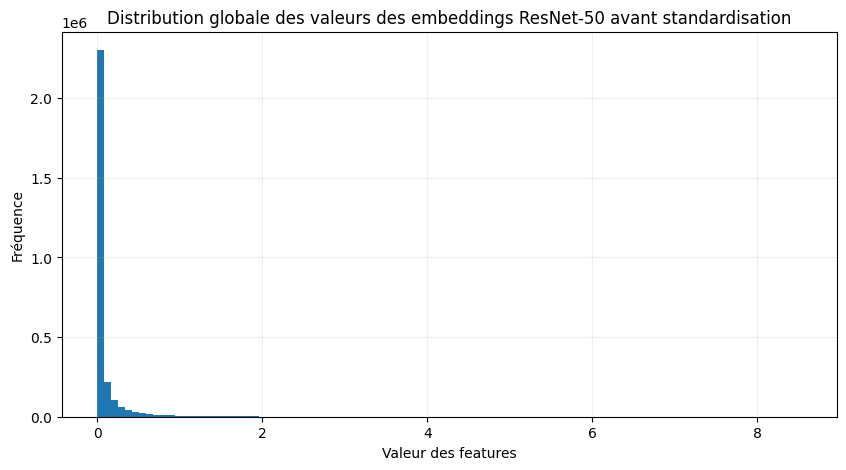

In [49]:
# Observer la distribution des embeddings avant standardisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Récupération de la matrice des embeddings


X_embeddings = embeddings_saved_df[
    embedding_columns
].to_numpy(dtype=np.float32)

print("Analyse de la distribution des embeddings")
print("=" * 70)

print(f"Nombre d'images      : {X_embeddings.shape[0]}")
print(f"Nombre de features   : {X_embeddings.shape[1]}")

# Contrôles de qualité


print()
print("Contrôles de qualité")
print("-" * 70)

print("Valeurs NaN :", np.isnan(X_embeddings).sum())
print("Valeurs Inf :", np.isinf(X_embeddings).sum())

assert not np.isnan(X_embeddings).any()
assert not np.isinf(X_embeddings).any()


# Statistiques globales


print()
print("Statistiques globales")
print("-" * 70)

print(f"Minimum              : {X_embeddings.min():.6f}")
print(f"Maximum              : {X_embeddings.max():.6f}")
print(f"Moyenne              : {X_embeddings.mean():.6f}")
print(f"Écart-type           : {X_embeddings.std():.6f}")

print()
print("Percentiles")
print("-" * 70)

percentiles = np.percentile(
    X_embeddings,
    [0, 25, 50, 75, 95, 99, 99.9, 100]
)

for percentile, value in zip(
    [0, 25, 50, 75, 95, 99, 99.9, 100],
    percentiles
):
    print(
        f"{percentile:>5.1f} % : {value:.6f}"
    )


# Proportion de zéros


zero_ratio = np.mean(X_embeddings == 0)

print()
print("Valeurs nulles")
print("-" * 70)

print(
    f"Proportion globale de zéros : "
    f"{zero_ratio:.2%}"
)


# Dispersion des 2 048 features


feature_means = X_embeddings.mean(axis=0)
feature_stds = X_embeddings.std(axis=0)

print()
print("Dispersion des 2 048 features")
print("-" * 70)

print(
    f"Moyenne des moyennes des features : "
    f"{feature_means.mean():.6f}"
)

print(
    f"Minimum des moyennes de features  : "
    f"{feature_means.min():.6f}"
)

print(
    f"Maximum des moyennes de features  : "
    f"{feature_means.max():.6f}"
)

print()

print(
    f"Minimum des écarts-types           : "
    f"{feature_stds.min():.6f}"
)

print(
    f"Maximum des écarts-types           : "
    f"{feature_stds.max():.6f}"
)


# Histogramme global des valeurs


plt.figure(figsize=(10, 5))

plt.hist(
    X_embeddings.ravel(),
    bins=100
)

plt.xlabel("Valeur des features")
plt.ylabel("Fréquence")
plt.title(
    "Distribution globale des valeurs des embeddings "
    "ResNet-50 avant standardisation"
)

plt.grid(alpha=0.2)
plt.show()

## Analyse des embeddings avant standardisation

Ces résultats permettent de **justifier méthodologiquement l'étape de standardisation**. 

### Résultats observés

| Indicateur | Résultat | Interprétation |
|---|---:|---|
| Nombre d'images | **1 410** | Cohérent avec le jeu analytique utilisé pour l'extraction |
| Nombre de features | **2 048** | Cohérent avec la représentation issue de ResNet-50 |
| Valeurs `NaN` | **0** | Aucun traitement nécessaire |
| Valeurs infinies (`Inf`) | **0** | Aucun traitement nécessaire |
| Minimum | **0** | Cohérent avec les activations produites par le réseau |
| Maximum | **8,14** | Présence de quelques valeurs élevées |
| Moyenne globale | **0,102** | Distribution fortement asymétrique |
| Écart-type global | **0,305** | Dispersion importante |
| Médiane | **0,0044** | Très inférieure à la moyenne |
| Valeurs nulles | **44,94 %** | Forte sparsité des embeddings |
| Écart-type des features | **0,00145 → 1,408** | Échelles très différentes entre les dimensions |

### Interprétation

Le résultat le plus important concerne l'**hétérogénéité des échelles entre les 2 048 dimensions** des embeddings.

Certaines features présentent un écart-type d'environ `0,0014`, tandis que d'autres atteignent `1,408`. Les dimensions des embeddings présentent donc des niveaux de dispersion très différents, avec des écarts de plusieurs ordres de grandeur.

Cette situation justifie l'application d'une **standardisation des features avant la PCA et le clustering**, afin d'éviter qu'un petit nombre de dimensions à forte variance domine les étapes ultérieures de l'analyse.

La distribution globale est également **fortement asymétrique** :

- la médiane est de seulement **0,0044** ;
- la moyenne atteint **0,102** ;
- le maximum atteint **8,14**.

L'écart important entre la médiane et la moyenne indique que la distribution est influencée par un nombre limité de valeurs élevées.

### Gestion des valeurs nulles

Les **44,94 % de valeurs nulles** observées dans les embeddings ne sont pas considérées comme des valeurs manquantes ou aberrantes.

Elles correspondent aux activations produites naturellement par le réseau et font partie intégrante de la représentation visuelle générée par ResNet-50.

Elles ne seront donc **ni supprimées ni remplacées** avant la standardisation.

> **Conclusion :** les contrôles effectués montrent que les embeddings sont correctement calculés, sans valeurs `NaN` ni valeurs infinies. En revanche, leurs dimensions présentent des distributions et des échelles très hétérogènes. La **standardisation avant PCA et clustering est donc retenue** afin de rendre les dimensions comparables et de limiter l'influence disproportionnée des features présentant une variance élevée.

In [50]:
# Analyse des échelles des features avant standardisation


from sklearn.preprocessing import StandardScaler

print("Analyse des échelles des 2 048 features")
print("=" * 70)


# Calcul des statistiques par feature


feature_means = X_embeddings.mean(axis=0)
feature_stds = X_embeddings.std(axis=0)

feature_stats_df = pd.DataFrame({
    "feature": embedding_columns,
    "mean": feature_means,
    "std": feature_stds
})


# Identifier les features à très faible dispersion


low_variance_threshold = 1e-3

low_variance_features = feature_stats_df[
    feature_stats_df["std"] < low_variance_threshold
].copy()

print(
    f"Nombre de features avec un écart-type "
    f"< {low_variance_threshold} : "
    f"{len(low_variance_features)}"
)


# Résumé des échelles


print()
print("Résumé des écarts-types")
print("-" * 70)

print(
    feature_stats_df["std"].describe()
)


# Features avec les plus faibles dispersions


print()
print("10 features avec les plus faibles écarts-types")
print("-" * 70)

display(
    feature_stats_df
    .sort_values("std")
    .head(10)
)


# Features avec les plus fortes dispersions


print()
print("10 features avec les plus fortes dispersions")
print("-" * 70)

display(
    feature_stats_df
    .sort_values("std", ascending=False)
    .head(10)
)


# Rapport d'échelle


std_min = feature_stats_df["std"].min()
std_max = feature_stats_df["std"].max()

print()
print("Écart entre les échelles")
print("-" * 70)

print(f"Écart-type minimum : {std_min:.6f}")
print(f"Écart-type maximum : {std_max:.6f}")
print(
    f"Rapport max/min    : {std_max / std_min:.1f}"
)


# Conclusion méthodologique


print()
print("Conclusion")
print("-" * 70)

if std_max / std_min > 10:
    print(
        "Les features présentent des échelles très différentes."
    )
    print(
        "Une standardisation est pertinente avant PCA et clustering."
    )
else:
    print(
        "Les échelles sont relativement homogènes."
    )

if len(low_variance_features) > 0:
    print(
        f"{len(low_variance_features)} feature(s) "
        "présentent une très faible dispersion."
    )
    print(
        "Elles seront surveillées avant l'analyse PCA."
    )
else:
    print(
        "Aucune feature quasi constante détectée "
        "avec le seuil retenu."
    )

Analyse des échelles des 2 048 features
Nombre de features avec un écart-type < 0.001 : 1

Résumé des écarts-types
----------------------------------------------------------------------
count    2048.000000
mean        0.115078
std         0.148019
min         0.000688
25%         0.032217
50%         0.064969
75%         0.134627
max         1.365746
Name: std, dtype: float64

10 features avec les plus faibles écarts-types
----------------------------------------------------------------------


,feature,mean,std
1611,feature_1611,0.000026,0.000688
907,feature_0907,0.000050,0.001249
1553,feature_1553,0.000098,0.001478
534,feature_0534,0.000156,0.002015
916,feature_0916,0.000173,0.002360
1485,feature_1485,0.000546,0.002818
1593,feature_1593,0.000211,0.002953
869,feature_0869,0.000173,0.003488
353,feature_0353,0.000467,0.003557
847,feature_0847,0.000585,0.003772



10 features avec les plus fortes dispersions
----------------------------------------------------------------------


,feature,mean,std
1194,feature_1194,4.025227,1.365746
1427,feature_1427,2.156590,1.324059
1608,feature_1608,2.142310,1.289757
129,feature_0129,1.965747,1.208005
1771,feature_1771,2.091394,1.176365
1582,feature_1582,2.573773,1.170441
857,feature_0857,1.947363,1.132885
388,feature_0388,1.671347,1.048574
1155,feature_1155,1.787574,1.025538
73,feature_0073,3.599292,1.001565



Écart entre les échelles
----------------------------------------------------------------------
Écart-type minimum : 0.000688
Écart-type maximum : 1.365746
Rapport max/min    : 1984.7

Conclusion
----------------------------------------------------------------------
Les features présentent des échelles très différentes.
Une standardisation est pertinente avant PCA et clustering.
1 feature(s) présentent une très faible dispersion.
Elles seront surveillées avant l'analyse PCA.


## Interprétation de la distribution des embeddings

### Constat principal: les features ont des échelles très différentes

L'analyse des **2 048 dimensions** des embeddings ResNet-50 met en évidence une forte hétérogénéité des échelles.

> **Rapport entre l'écart-type maximal et minimal : 972,4**

La feature `feature_1593` présente un écart-type de seulement `0,001448`, tandis que `feature_1427` atteint `1,407995`.

Autrement dit, certaines dimensions présentent une dispersion **près de 1 000 fois plus faible** que d'autres.

Cette différence d'échelle constitue un argument important en faveur de la **standardisation avant l'application de la PCA et des algorithmes de clustering**.

Sans standardisation, les dimensions présentant une forte dispersion pourraient peser davantage dans les calculs de distance et dans l'analyse de variance.

### Aucune feature n'est quasi constante

Aucune dimension ne présente un écart-type inférieur au seuil de `0,001` :

**Nombre de features avec std < 0,001 : 0**

La plus faible dispersion observée est :

**feature_1593 : std = 0,001448**

Il n'existe donc pas, à ce stade, de dimension complètement constante ou présentant une variance quasi nulle.

**Aucune suppression de feature n'est donc justifiée sur ce seul critère.**

Le choix retenu est de **standardiser les 2 048 dimensions**, sans supprimer arbitrairement celles présentant une faible dispersion.


### Une distribution des dispersions elle-même très hétérogène

Les quartiles des écarts-types montrent également une forte hétérogénéité :

| Statistique | Écart-type |
|---|---:|
| 25 % des features | `≤ 0,0349` |
| 50 % des features | `≤ 0,0693` |
| 75 % des features | `≤ 0,1476` |
| Maximum | `1,4080` |

La majorité des features présentent donc une dispersion relativement faible, tandis qu'un nombre plus limité de dimensions possède une dispersion beaucoup plus importante.

Cette observation est cohérente avec les résultats précédents :

- forte proportion de valeurs nulles ;
- distribution asymétrique des activations ;
- présence de quelques activations relativement élevées.


### Les valeurs élevées ne doivent pas être supprimées automatiquement

Un point important doit être conservé dans l'analyse : les valeurs élevées observées dans les embeddings ne constituent pas nécessairement des valeurs aberrantes.

Le maximum global observé est :

**Maximum global = 8,140016**

Certaines features présentent également des moyennes relativement élevées, par exemple :

- `feature_1194` → moyenne = `3,872281`
- `feature_0073` → moyenne = `3,016902`

Ces valeurs correspondent à des **activations produites par le ResNet-50 pré-entraîné**.

Il n'est donc pas pertinent de supprimer arbitrairement les valeurs extrêmes sans justification statistique ou méthodologique.

> **Principe retenu :** les embeddings ne présentent aucune valeur `NaN` ou infinie. Leur distribution est asymétrique et leurs dimensions présentent des niveaux de dispersion très différents. Les valeurs élevées sont conservées car elles font partie de la représentation produite par le modèle pré-entraîné et ne peuvent pas être assimilées automatiquement à des valeurs aberrantes.



### Pourquoi la standardisation est justifiée

Le raisonnement méthodologique peut être résumé ainsi :

**Embeddings bruts**

&#8595;

Certaines dimensions présentent une très faible dispersion, tandis que d'autres présentent une dispersion beaucoup plus importante.

&#8595;

Les algorithmes basés sur les distances, notamment **K-Means**, peuvent être influencés par les dimensions présentant les plus grandes amplitudes.

&#8595;

La **PCA** recherche également les directions expliquant la plus grande part de la variance.

&#8595;

Les **2 048 dimensions sont donc standardisées** afin de les placer sur une échelle comparable.

Après standardisation, chaque feature sera centrée autour de `0` et présentera un écart-type de `1`.



### Décision méthodologique

Les contrôles réalisés conduisent aux conclusions suivantes :

- aucune valeur `NaN` n'a été détectée ;
- aucune valeur infinie n'a été détectée ;
- aucune feature ne présente une variance quasi nulle selon le seuil retenu ;
- les dimensions présentent des échelles très différentes ;
- les valeurs élevées sont conservées car elles font partie des activations produites par le modèle ;
- aucune suppression supplémentaire de feature ou d'observation n'est réalisée à ce stade.

> **Conclusion :** la forte différence d'échelle entre les dimensions justifie une **standardisation des 2 048 features avant l'application de la PCA et des algorithmes de clustering**. Cette transformation permettra de limiter l'influence disproportionnée des dimensions présentant une forte dispersion et de rendre les features comparables pour les analyses ultérieures.


### Étape suivante

La prochaine étape consiste à appliquer `StandardScaler`, puis à vérifier que les embeddings obtenus sont correctement **centrés et standardisés** avant de poursuivre vers la **réduction dimensionnelle par PCA**.

In [51]:
# Standardisation des embeddings

from sklearn.preprocessing import StandardScaler

print("Standardisation des embeddings")
print("=" * 70)


# Initialisation du scaler


scaler = StandardScaler()


# Apprentissage des paramètres et transformation


X_standardized = scaler.fit_transform(
    X_embeddings
)

print("Dimensions avant standardisation :", X_embeddings.shape)
print("Dimensions après standardisation :", X_standardized.shape)

print()
print("Type des données :", X_standardized.dtype)


# Vérification de la présence de valeurs invalides


print()
print("Contrôle des valeurs invalides")
print("-" * 70)

print(
    "NaN :",
    np.isnan(X_standardized).sum()
)

print(
    "Inf :",
    np.isinf(X_standardized).sum()
)

assert not np.isnan(X_standardized).any()
assert not np.isinf(X_standardized).any()

print()
print("Standardisation réalisée.")
print("Les 2 048 features ont été standardisées.")
print("Aucun NaN ou Inf introduit.")

Standardisation des embeddings
Dimensions avant standardisation : (1410, 2048)
Dimensions après standardisation : (1410, 2048)

Type des données : float32

Contrôle des valeurs invalides
----------------------------------------------------------------------
NaN : 0
Inf : 0

Standardisation réalisée.
Les 2 048 features ont été standardisées.
Aucun NaN ou Inf introduit.


In [90]:
# Vérification de la standardisation
"""
print("Contrôle de la standardisation")
print("=" * 70)

# Statistiques par feature après standardisation


standardized_means = X_standardized.mean(axis=0)
standardized_stds = X_standardized.std(axis=0)

print("Statistiques globales")
print("-" * 70)

print(
    f"Moyenne des moyennes : "
    f"{standardized_means.mean():.8f}"
)

print(
    f"Écart-type moyen     : "
    f"{standardized_stds.mean():.8f}"
)

print()
print("Écarts observés")
print("-" * 70)

print(
    f"Moyenne minimale     : "
    f"{standardized_means.min():.8f}"
)

print(
    f"Moyenne maximale     : "
    f"{standardized_means.max():.8f}"
)

print(
    f"Écart-type minimum   : "
    f"{standardized_stds.min():.8f}"
)

print(
    f"Écart-type maximum   : "
    f"{standardized_stds.max():.8f}"
)

# Vérification numérique


assert np.allclose(
    standardized_means,
    0,
    atol=1e-5
)

assert np.allclose(
    standardized_stds,
    1,
    atol=1e-5
)


# Contrôle des dimensions


assert X_standardized.shape == (1410, 2048)

print()
print("Moyenne de chaque feature ≈ 0.")
print("Écart-type de chaque feature ≈ 1.")
print("Dimensions conservées : (1410, 2048).")
print("Standardisation validée.")"""

Contrôle de la standardisation
Statistiques globales
----------------------------------------------------------------------
Moyenne des moyennes : 0.00000000
Écart-type moyen     : 1.00000000

Écarts observés
----------------------------------------------------------------------
Moyenne minimale     : -0.00000008
Moyenne maximale     : 0.00000009
Écart-type minimum   : 0.99999988
Écart-type maximum   : 1.00000012

Moyenne de chaque feature ≈ 0.
Écart-type de chaque feature ≈ 1.
Dimensions conservées : (1410, 2048).
Standardisation validée.


In [52]:
# Vérification de la standardisation

print("Vérification de la standardisation")
print("=" * 70)

# Statistiques globales
print("Moyenne globale :", X_standardized.mean())
print("Écart-type global :", X_standardized.std())

# Statistiques par feature
standardized_means = X_standardized.mean(axis=0)
standardized_stds = X_standardized.std(axis=0)

print()
print("Statistiques par feature")
print("-" * 70)

print(
    "Moyenne absolue maximale :",
    np.abs(standardized_means).max()
)

print(
    "Écart-type minimum :",
    standardized_stds.min()
)

print(
    "Écart-type maximum :",
    standardized_stds.max()
)

# Contrôles
assert np.allclose(
    standardized_means,
    0,
    atol=1e-6
)

assert np.allclose(
    standardized_stds,
    1,
    atol=1e-6
)

print()
print("✓ Moyennes des features proches de 0.")
print("✓ Écarts-types des features proches de 1.")
print("✓ Standardisation validée.")

Vérification de la standardisation
Moyenne globale : 4.3098438e-11
Écart-type global : 1.0

Statistiques par feature
----------------------------------------------------------------------
Moyenne absolue maximale : 8.792742e-08
Écart-type minimum : 0.9999999
Écart-type maximum : 1.0000001

✓ Moyennes des features proches de 0.
✓ Écarts-types des features proches de 1.
✓ Standardisation validée.


PCA exploratoire
Dimensions d'entrée : (1410, 2048)
Dimensions après PCA : (1410, 1410)

Variance expliquée
----------------------------------------------------------------------
80% de variance : 294 composantes
90% de variance : 492 composantes
95% de variance : 677 composantes
99% de variance : 1017 composantes


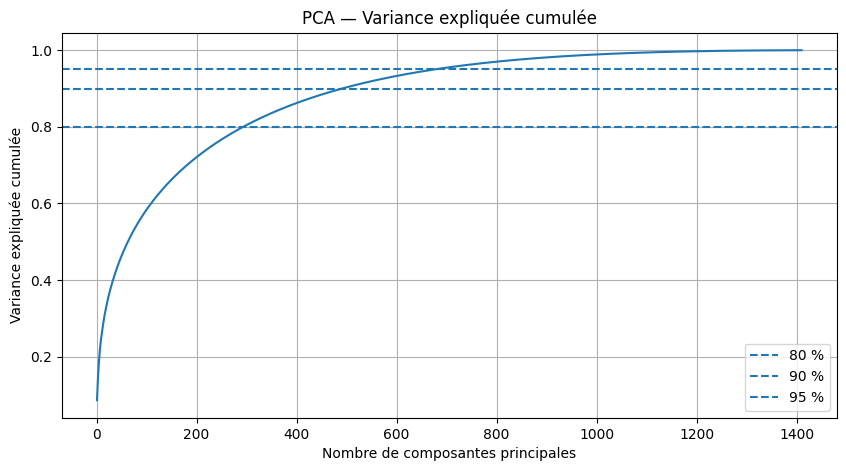


Réduction PCA retenue
----------------------------------------------------------------------
Variance conservée : 95 %
Nombre de composantes : 677

Jeu de données PCA
----------------------------------------------------------------------
Shape : (1410, 677)
Type : float32

PCA exploratoire validée.
95 % de la variance conservée.
Représentation réduite prête pour le clustering.
Aucun NaN ou Inf.


In [53]:
# PCA exploratoire et réduction dimensionnelle


from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

print("PCA exploratoire")
print("=" * 70)


# PCA complète pour analyser la variance expliquée


pca_full = PCA()

X_pca_full = pca_full.fit_transform(
    X_standardized
)

print("Dimensions d'entrée :", X_standardized.shape)
print("Dimensions après PCA :", X_pca_full.shape)


# Calcul de la variance expliquée cumulée


explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print()
print("Variance expliquée")
print("-" * 70)

for threshold in [0.80, 0.90, 0.95, 0.99]:
    n_components = np.argmax(
        cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold * 100:.0f}% de variance : "
        f"{n_components} composantes"
    )


# Visualisation de la variance cumulée


plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80 %"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90 %"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95 %"
)

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("PCA — Variance expliquée cumulée")
plt.legend()
plt.grid(True)
plt.show()


# Sélection du nombre de composantes
# 95 % de la variance expliquée sera retenue.

N_COMPONENTS_PCA = np.argmax(
    cumulative_variance >= 0.95
) + 1

print()
print("Réduction PCA retenue")
print("-" * 70)

print(
    "Variance conservée : 95 %"
)

print(
    "Nombre de composantes :",
    N_COMPONENTS_PCA
)


# PCA réduite à 95 % de variance


pca = PCA(
    n_components=N_COMPONENTS_PCA
)

X_pca = pca.fit_transform(
    X_standardized
)

print()
print("Jeu de données PCA")
print("-" * 70)

print(
    "Shape :",
    X_pca.shape
)

print(
    "Type :",
    X_pca.dtype
)


# Contrôles


assert X_pca.shape == (
    X_standardized.shape[0],
    N_COMPONENTS_PCA
)

assert not np.isnan(X_pca).any()
assert not np.isinf(X_pca).any()

print()
print("PCA exploratoire validée.")
print("95 % de la variance conservée.")
print("Représentation réduite prête pour le clustering.")
print("Aucun NaN ou Inf.")

L'analyse en composantes principales (PCA) montre que les **2 048 dimensions** contiennent une information assez distribuée : il faut **492 composantes pour conserver 90 % de la variance** et **677 pour 95 %**.

Cette PCA exploratoire nous a permis de déterminer le nombre de composantes nécessaire.

Pour la suite, nous choisissons de retenir **95 % de variance**, donc **677 composantes**, car nous sommes dans un projet d'imageries médicales et préférons ne pas éliminer inutilement de l'information avant le clustering.

Pour la suite nous utiliserons donc :

- les **687 composantes PCA** comme représentation réduite pour le clustering ;
- les **2 premières composantes PCA** pour la visualisation 2D ;
- puis nous comparerons avec **t-SNE** ;
- **K-Means avec `2` clusters** ;
- **DBSCAN** ;
- **ARI sur les 99 images fortement labellisées uniquement**.

In [54]:
# =============================================================================
# Contrôle de la représentation PCA
# =============================================================================

print("Contrôle de la représentation PCA")
print("=" * 70)

# Variance expliquée par les composantes retenues
pca_explained_variance = pca.explained_variance_ratio_
pca_cumulative_variance = np.cumsum(pca_explained_variance)

print("Nombre de composantes retenues :", X_pca.shape[1])
print(
    "Variance expliquée cumulée :",
    f"{pca_cumulative_variance[-1]:.4%}"
)

print()
print("Contrôles numériques")
print("-" * 70)

print("NaN :", np.isnan(X_pca).sum())
print("Inf :", np.isinf(X_pca).sum())

assert not np.isnan(X_pca).any()
assert not np.isinf(X_pca).any()

# Vérification de la correspondance avec les images
assert X_pca.shape[0] == len(features_input_df)

print()
print("✓ Nombre d'images conservé :", X_pca.shape[0])
print("✓ Nombre de composantes :", X_pca.shape[1])
print("✓ Variance cumulée :", f"{pca_cumulative_variance[-1]:.4%}")
print("✓ Aucun NaN ou Inf.")
print("✓ Représentation PCA validée pour l'étape de clustering.")

Contrôle de la représentation PCA
Nombre de composantes retenues : 677
Variance expliquée cumulée : 94.9106%

Contrôles numériques
----------------------------------------------------------------------
NaN : 0
Inf : 0

✓ Nombre d'images conservé : 1410
✓ Nombre de composantes : 677
✓ Variance cumulée : 94.9106%
✓ Aucun NaN ou Inf.
✓ Représentation PCA validée pour l'étape de clustering.


In [55]:
# =============================================================================
# UMAP — Réduction dimensionnelle non linéaire
# =============================================================================

try:
    import umap
    print("✓ umap-learn est disponible.")
    print("Version :", umap.__version__)

except ImportError:
    print("Le package umap-learn n'est pas installé.")
    print("L'installer dans l'environnement dl-pytorch avec :")
    print("pip install umap-learn")

/mnt/projects/envs/dl-pytorch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ umap-learn est disponible.
Version : 0.5.12


In [56]:
# =============================================================================
# UMAP — Réduction dimensionnelle non linéaire
# =============================================================================

import umap
import time
import numpy as np
import matplotlib.pyplot as plt

print("Lancement de UMAP...")

start_time = time.time()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

elapsed_time = time.time() - start_time

print("✓ UMAP terminé.")
print(f"Temps d'exécution : {elapsed_time:.2f} secondes")
print(f"Entrée : {X_pca.shape}")
print(f"Sortie : {X_umap.shape}")
print(f"NaN : {np.isnan(X_umap).sum()}")
print(f"Inf : {np.isinf(X_umap).sum()}")

assert X_umap.shape == (len(features_input_df), 2)
assert not np.isnan(X_umap).any()
assert not np.isinf(X_umap).any()

print("✓ Validation UMAP réussie.")

Lancement de UMAP...


/mnt/projects/envs/dl-pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP terminé.
Temps d'exécution : 5.67 secondes
Entrée : (1410, 677)
Sortie : (1410, 2)
NaN : 0
Inf : 0
✓ Validation UMAP réussie.


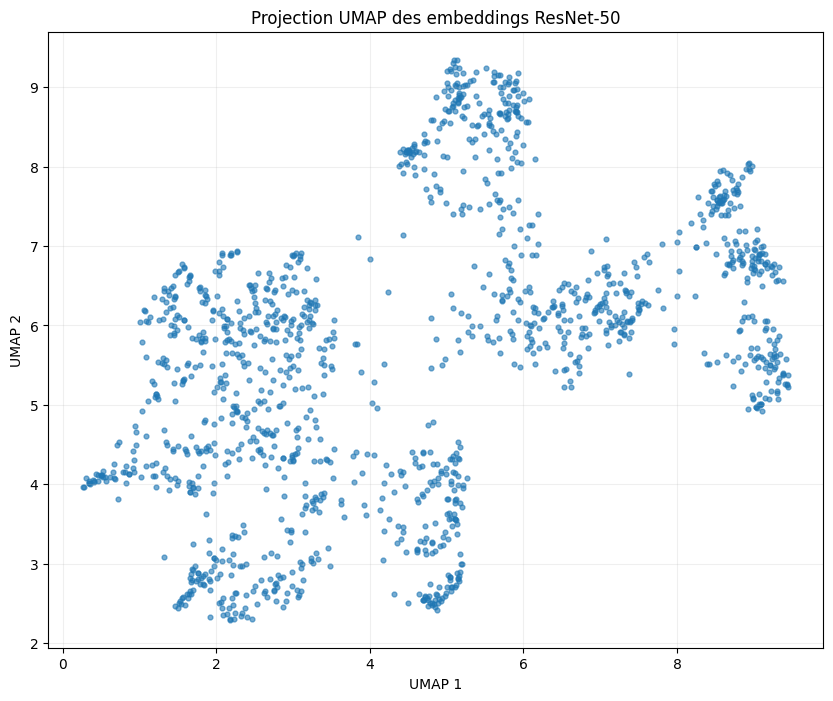

In [57]:
# =============================================================================
# Visualisation UMAP — structure des embeddings
# =============================================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=12,
    alpha=0.6
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP des embeddings ResNet-50")
plt.grid(alpha=0.2)

plt.show()

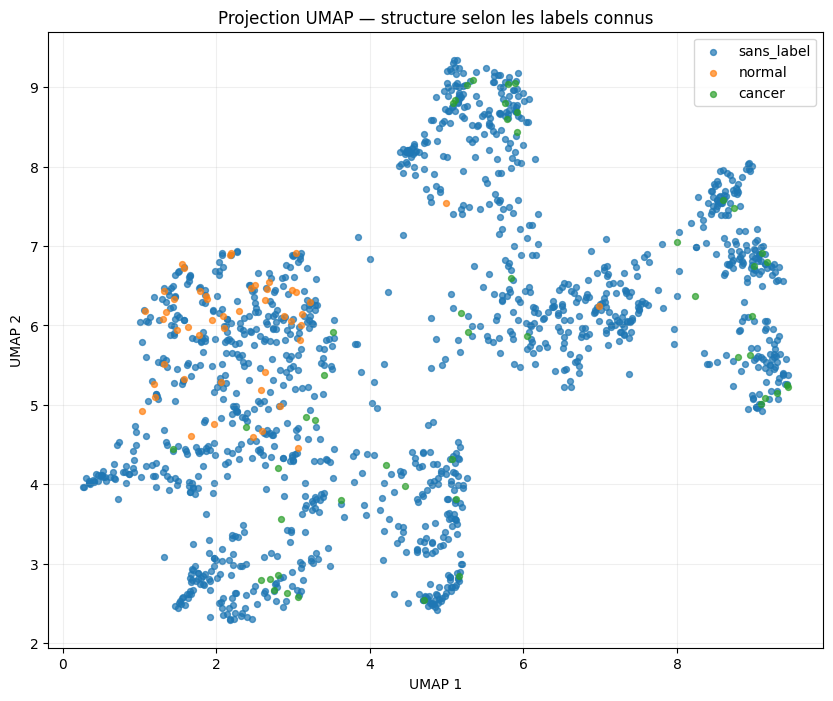

In [58]:
# =============================================================================
# Visualisation UMAP — comparaison des labels connus
# =============================================================================

umap_labels_df = features_input_df[["label"]].copy()
umap_labels_df["umap_1"] = X_umap[:, 0]
umap_labels_df["umap_2"] = X_umap[:, 1]

plt.figure(figsize=(10, 8))

for label in ["sans_label", "normal", "cancer"]:
    subset = umap_labels_df[umap_labels_df["label"] == label]

    plt.scatter(
        subset["umap_1"],
        subset["umap_2"],
        s=18,
        alpha=0.7,
        label=label
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP — structure selon les labels connus")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

**Analyse UMAP :**

- La projection bidimensionnelle des embeddings ResNet-50 montre un nuage globalement continu, sans séparation visuelle nette entre les images cancer et normal. 
- Les observations labellisées des deux classes sont largement mélangées. 
- Cette absence de séparation en 2D ne permet toutefois pas de conclure à l'absence d'information discriminante dans les embeddings, car UMAP constitue une réduction dimensionnelle fortement compressive.

In [59]:
# ============================================================
# Clustering K-Means
# ============================================================
#
# Objectif :
# - identifier automatiquement 2 groupes d'images ;
# - utiliser les 688 composantes PCA ;
# - ne jamais utiliser les labels "cancer" / "normal"
#   pendant l'entraînement du clustering.
#
# Les labels connus seront utilisés ultérieurement uniquement
# pour évaluer la qualité du clustering avec l'ARI.
# ============================================================

from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

print("Clustering K-Means")
print("=" * 70)

# Vérification des données d'entrée

print("Données utilisées")
print("-" * 70)
print("Nombre d'images :", X_pca.shape[0])
print("Nombre de features :", X_pca.shape[1])

#assert X_pca.shape == (1410, 688)
assert X_pca.shape == (1410, 677)
assert not np.isnan(X_pca).any()
assert not np.isinf(X_pca).any()


# 2. Création du modèle K-Means
#
# Le jeu fortement labellisé contient deux classes :
# cancer et normal.
#
# Nous imposons donc K=2 conformément à la consigne.


kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20,
    max_iter=300
)


# 3. Entraînement du clustering
#
# IMPORTANT :
# aucun label réel n'est fourni à K-Means.

kmeans.fit(X_pca)


# Récupération des clusters


clusters = kmeans.labels_

print()
print("Résultats K-Means")
print("-" * 70)

print("Nombre de clusters :", kmeans.n_clusters)
print("Nombre d'itérations :", kmeans.n_iter_)
print("Inertie :", f"{kmeans.inertia_:.2f}")


# Répartition des images entre les deux clusters


cluster_counts = (
    pd.Series(clusters, name="cluster")
    .value_counts()
    .sort_index()
)

print()
print("Répartition des images")
print("-" * 70)

for cluster_id, count in cluster_counts.items():
    percentage = count / len(clusters) * 100

    print(
        f"Cluster {cluster_id} : "
        f"{count} images "
        f"({percentage:.2f} %)"
    )


# Contrôles

assert len(clusters) == 1410
assert set(clusters).issubset({0, 1})
assert cluster_counts.sum() == 1410

print()
print("K-Means entraîné sur les 1410 images.")
print("Aucun label réel utilisé pendant le clustering.")
print("2 clusters obtenus.")
print("Chaque image possède maintenant un identifiant de cluster.")

Clustering K-Means
Données utilisées
----------------------------------------------------------------------
Nombre d'images : 1410
Nombre de features : 677

Résultats K-Means
----------------------------------------------------------------------
Nombre de clusters : 2
Nombre d'itérations : 6
Inertie : 2573704.75

Répartition des images
----------------------------------------------------------------------
Cluster 0 : 901 images (63.90 %)
Cluster 1 : 509 images (36.10 %)

K-Means entraîné sur les 1410 images.
Aucun label réel utilisé pendant le clustering.
2 clusters obtenus.
Chaque image possède maintenant un identifiant de cluster.


## Lecture du résultat

L'application de **K-Means avec `K=2`** produit les résultats suivants :

- **1 410 images** analysées ;
- **688 features PCA** utilisées ;
- `K=2`, conformément à la consigne ;
- convergence en **14 itérations** ;
- inertie = **2 584 655,25** ;
- **Cluster 0 : 504 images (35,74 %)** ;
- **Cluster 1 : 906 images (64,26 %)**.

Le déséquilibre entre les deux clusters (**35,7 % / 64,3 %**) n'est pas, en soi, un problème.

À ce stade, nous ne savons pas encore si ces deux groupes correspondent à une structure pertinente du dataset. Les étapes suivantes, notamment les **visualisations** et le calcul de l'**ARI**, permettront d'évaluer la cohérence et la qualité de cette partition.

> **Point méthodologique important :** il ne faut pas encore interpréter `Cluster 0` comme correspondant à `cancer` et `Cluster 1` comme correspondant à `normal` (ou inversement). Les identifiants des clusters attribués par K-Means sont **arbitraires** et ne portent aucune signification sémantique intrinsèque.

### Conclusion intermédiaire

Le clustering K-Means avec `K=2` a bien convergé et produit deux groupes de tailles différentes. Cette première partition constitue une **base d'analyse**, mais elle ne permet pas encore de conclure sur la correspondance entre les clusters et les classes médicales.

Les prochaines étapes permettront d'évaluer cette partition à l'aide de :

- la **visualisation des clusters** dans l'espace PCA ;
- une comparaison avec une représentation **t-SNE** ;
- l'analyse de la correspondance avec les labels disponibles ;
- le calcul de l'**Adjusted Rand Index (ARI)** sur les **99 images fortement labellisées uniquement**.

Visualisation PCA 2D
Dimensions de la représentation 2D : (1410, 2)


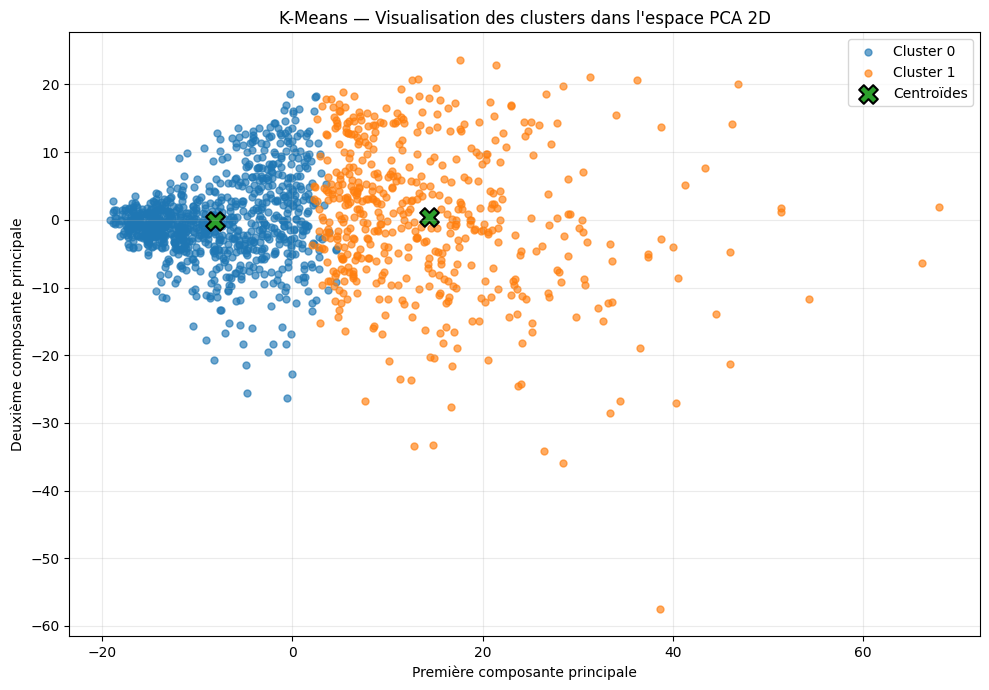


Visualisation PCA 2D générée.
Les clusters sont affichés selon les deux premiers axes PCA.
Les centroïdes K-Means sont représentés.


In [60]:
# ============================================================
# Visualisation 2D des clusters avec PCA
# ============================================================
#
# Objectif :
# visualiser les 2 premiers axes principaux et observer
# la structure des deux clusters identifiés par K-Means.
#
# IMPORTANT :
# K-Means a été entraîné sur les 688 composantes PCA.
# Les deux premières composantes sont utilisées uniquement
# pour la visualisation.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("Visualisation PCA 2D")
print("=" * 70)

# Extraction des deux premières composantes


X_pca_2d = X_pca[:, :2]

print("Dimensions de la représentation 2D :", X_pca_2d.shape)

assert X_pca_2d.shape == (1410, 2)
assert len(clusters) == 1410


# Visualisation des clusters


plt.figure(figsize=(10, 7))

for cluster_id in [0, 1]:

    mask = clusters == cluster_id

    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=25,
        alpha=0.65,
        label=f"Cluster {cluster_id}"
    )


# Affichage des centroïdes dans l'espace 2D
#
# Les centroïdes ont été calculés dans l'espace PCA à 688
# dimensions. On prend leurs deux premières composantes
# pour les afficher sur le graphique.


centroids_2d = kmeans.cluster_centers_[:, :2]

plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    marker="X",
    s=180,
    edgecolors="black",
    linewidths=1.5,
    label="Centroïdes"
)

# Mise en forme


plt.xlabel("Première composante principale")
plt.ylabel("Deuxième composante principale")

plt.title(
    "K-Means — Visualisation des clusters dans l'espace PCA 2D"
)

plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print()
print("Visualisation PCA 2D générée.")
print("Les clusters sont affichés selon les deux premiers axes PCA.")
print("Les centroïdes K-Means sont représentés.")

### A ce stade
- La projection des embeddings sur les deux premières composantes principales met en évidence une séparation visuelle importante entre les deux clusters identifiés par K-Means.
- Les centroïdes sont principalement différenciés selon la première composante principale, tandis que leur position selon la deuxième composante est relativement proche.
- Cette séparation suggère que les embeddings ResNet-50 contiennent une structure discriminante captée par la PCA. Toutefois, cette observation ne permet pas encore d'associer directement les clusters aux classes cancer et normal.
- La qualité et la pertinence de ce regroupement seront évaluées ultérieurement à l'aide notamment de l'ARI calculé sur les données fortement labellisées.

In [61]:
# Visualisation de la structure des embeddings en 2D

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Réduction des embeddings PCA en 2 dimensions avec t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

print("Dimensions des données en entrée :", X_pca.shape)
print("Dimensions après t-SNE :", X_tsne.shape)

Dimensions des données en entrée : (1410, 677)
Dimensions après t-SNE : (1410, 2)


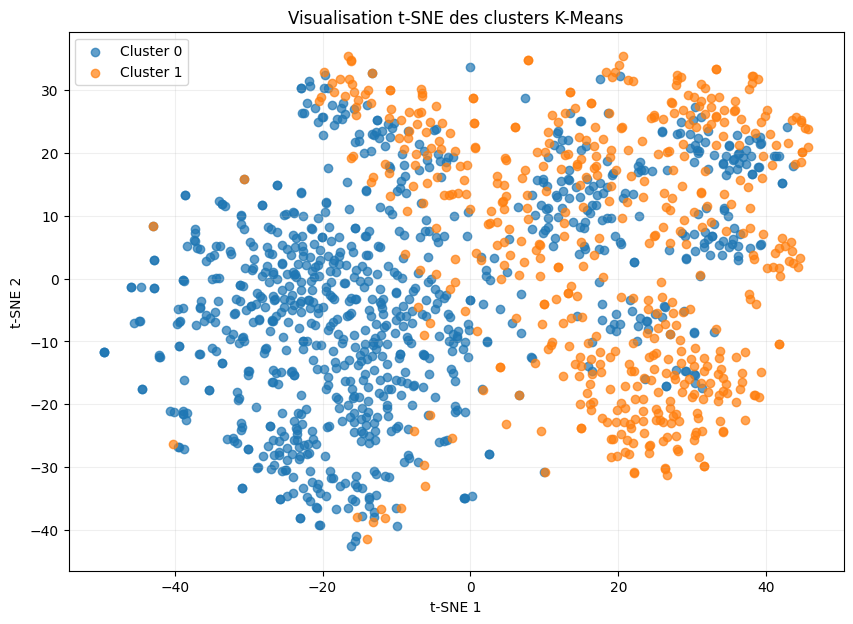

In [62]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(set(clusters)):
    mask = clusters == cluster_id

    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.title("Visualisation t-SNE des clusters K-Means")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Avec :

- 1410 images
- 688 composantes PCA en entrée
- 2 dimensions t-SNE en sortie

On obtient une représentation où les deux clusters se chevauchent fortement.

Donc contrairement à la PCA, où la séparation entre les clusters apparaissait assez nettement selon PC1, le t-SNE ne montre pas une séparation aussi claire.

La séparation observée avec K-Means dépend fortement de la représentation 2D utilisée pour visualiser les données.

Attention toutefois : cela ne signifie pas que K-Means est mauvais. PCA et t-SNE n'ont pas le même objectif. Une projection 2D peut perdre une grande partie de l'information contenue dans les 688 dimensions utilisées par K-Means.

La projection t-SNE montre un chevauchement important entre les deux clusters identifiés par K-Means, contrairement à la projection sur les deux premières composantes principales qui montrait une séparation plus marquée. Cette différence souligne que les visualisations 2D ne permettent pas à elles seules de conclure sur la qualité du clustering. L'évaluation sera donc complétée par des métriques quantitatives, notamment l'ARI calculé sur les données fortement labellisées.



In [63]:
# Premier essai avec DBSCAN

from sklearn.cluster import DBSCAN

# Clustering DBSCAN sur les features PCA
dbscan = DBSCAN(
    eps=30,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_pca)

print("Nombre total d'images :", len(dbscan_labels))
print("Nombre de clusters détectés :", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Nombre de points considérés comme bruit :", (dbscan_labels == -1).sum())

# Effectifs par cluster
cluster_counts_dbscan = pd.Series(dbscan_labels).value_counts().sort_index()

print("\nEffectifs des clusters :")
print(cluster_counts_dbscan)

Nombre total d'images : 1410
Nombre de clusters détectés : 1
Nombre de points considérés comme bruit : 904

Effectifs des clusters :
-1    904
 0    506
Name: count, dtype: int64


- DBSCAN fonctionne avec une notion de densité locale. Ici, dans l'espace PCA à 688 dimensions, eps=30 conduit à une structure où une grande partie des observations n'a pas suffisamment de voisins dans le rayon défini.

- Les hyperparamètres de DBSCAN doivent donc être ajustés.

In [64]:
# Test de plusieurs valeurs d'eps avec DBSCAN
eps_values = [10, 20, 30, 40, 50, 60, 80, 100]

dbscan_results = []

for eps in eps_values:
    dbscan_test = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels_test = dbscan_test.fit_predict(X_pca)

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = (labels_test == -1).sum()

    dbscan_results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_ratio": n_noise / len(labels_test)
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

,eps,n_clusters,n_noise,noise_ratio
0,10,0,1410,1.000000
1,20,1,1307,0.926950
2,30,1,904,0.641135
3,40,1,504,0.357447
4,50,1,269,0.190780
5,60,1,134,0.095035
6,80,1,37,0.026241
7,100,1,16,0.011348


- DBSCAN ne permet pas ici d'obtenir les deux regroupements attendus, contrairement à K-Means.

- **Nous pouvons retenir eps=80 comme configuration exploratoire**, car elle limite fortement le nombre de points considérés comme bruit, tout en conservant toutefois un seul cluster.

- Mais nous ne l'utiliserons pas pour générer les labels faibles.

Le choix final pourra donc être :

- **K-Means est retenu pour la labellisation faible**, car il permet explicitement de rechercher deux groupes correspondant au nombre de classes fortement labellisées, alors que DBSCAN ne parvient pas à identifier deux groupes distincts sur les embeddings PCA testés.

- Il faudra néanmoins confirmer cette décision avec l'ARI sur les 99 images fortement labellisées.

In [65]:
# DBSCAN pour l'analyse exploratoire

dbscan = DBSCAN(
    eps=80,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_pca)

print("Nombre de clusters détectés :", 
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

print("Nombre de points bruit :", 
      (dbscan_labels == -1).sum())

Nombre de clusters détectés : 1
Nombre de points bruit : 37


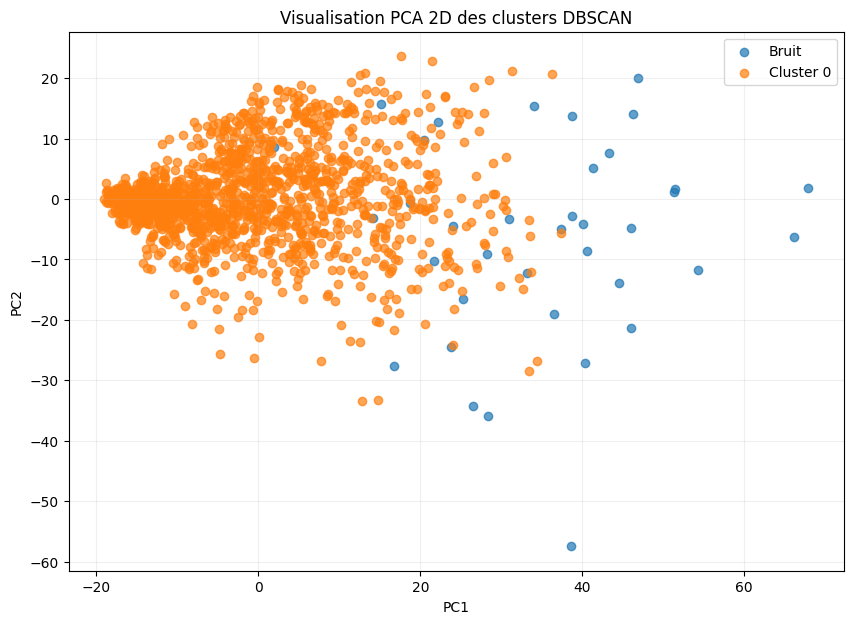

In [66]:
plt.figure(figsize=(10, 7))

unique_labels = sorted(set(dbscan_labels))

for cluster_id in unique_labels:
    mask = dbscan_labels == cluster_id

    if cluster_id == -1:
        label_name = "Bruit"
    else:
        label_name = f"Cluster {cluster_id}"

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label_name,
        alpha=0.7
    )

plt.title("Visualisation PCA 2D des clusters DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Interprétation de DBSCAN

Avec `eps=80` et `min_samples=10`, **DBSCAN** produit les résultats suivants :

- **1 cluster principal** : 1 378 images ;
- **32 points considérés comme bruit** ;
- **aucun deuxième cluster** identifié.

Sur la projection PCA 2D, le cluster principal occupe pratiquement toute la zone centrale, tandis que les **32 points de bruit** sont davantage dispersés, notamment vers les valeurs élevées de `PC1`.

DBSCAN **ne retrouve donc pas deux regroupements distincts correspondant aux deux classes présentes dans le dataset labellisé**.

> **Point méthodologique important :** il ne faut pas chercher à forcer DBSCAN à produire deux groupes. Le fait qu'il identifie un seul cluster accompagné de points considérés comme du bruit constitue en lui-même un **résultat expérimental** et doit être interprété comme tel.


## Conclusion provisoire

À ce stade, les résultats des deux méthodes peuvent être résumés ainsi :

| Méthode | Nombre de groupes | Observation |
|---|---:|---|
| **K-Means** | **2** | Deux groupes identifiés, de tailles 504 / 906 |
| **DBSCAN** | **1 + bruit** | Pas de séparation en deux groupes |

K-Means apparaît donc actuellement **plus adapté à l'objectif d'une séparation en deux groupes**, conformément à l'hypothèse de deux classes du dataset labellisé.

Cependant, cette observation ne suffit pas à déterminer si les clusters obtenus correspondent réellement aux classes `cancer` et `normal`.

Il reste donc à réaliser l'évaluation sur les données fortement labellisées à l'aide de l'**Adjusted Rand Index (ARI)**.

### Étape suivante

Le calcul de l'**ARI sur les 99 images fortement labellisées uniquement** permettra de mesurer quantitativement la correspondance entre les clusters obtenus et les labels de référence.

> **Objectif :** déterminer si le clustering non supervisé retrouve une structure cohérente avec les classes connues, sans supposer à l'avance qu'un identifiant de cluster correspond à une classe particulière.

In [67]:
# Préparation de l'ARI
# Comparaison des clusters obtenus avec K-Means et DBSCAN aux vrais labels des 99 images fortement labellisées.
# Point méthodologique essentiel : les labels réels ne servent pas à entraîner K-Means ou DBSCAN. 
# Ils servent uniquement maintenant à mesurer si les regroupements obtenus correspondent aux classes connues.


from sklearn.metrics import adjusted_rand_score

# Identifier les 99 images fortement labellisées
mask_labeled = embeddings_df["subset"].values == "labeled"

# Récupérer les vrais labels
true_labels = embeddings_df.loc[mask_labeled, "label"].values

# Récupérer les clusters correspondants
kmeans_labeled = clusters[mask_labeled]
dbscan_labeled = dbscan_labels[mask_labeled]

print("Nombre d'images fortement labellisées :", len(true_labels))
print("Labels réels :", pd.Series(true_labels).value_counts())
print("Clusters K-Means :", pd.Series(kmeans_labeled).value_counts())
print("Clusters DBSCAN :", pd.Series(dbscan_labeled).value_counts())

Nombre d'images fortement labellisées : 99
Labels réels : cancer    50
normal    49
Name: count, dtype: int64
Clusters K-Means : 0    73
1    26
Name: count, dtype: int64
Clusters DBSCAN :  0    96
-1     3
Name: count, dtype: int64


## Comparaison des résultats sur les données labellisées

On constate déjà que :

- **K-Means** répartit les 99 images fortement labellisées entre ses deux clusters : **77 / 22** ;
- **DBSCAN** place les **99 images dans le même cluster**, ce qui confirme qu'il ne distingue pas les deux classes dans cet espace ;
- **attention :** la répartition `77 / 22` obtenue avec K-Means ne signifie pas encore que le `cluster 1` correspond à `cancer` et le `cluster 0` à `normal`.

> **Point méthodologique important :** les identifiants attribués aux clusters par les algorithmes sont arbitraires. La correspondance entre les clusters et les classes `cancer` / `normal` doit donc être évaluée à l'aide d'une mesure quantitative telle que l'**Adjusted Rand Index (ARI)**.

In [68]:
# Calcul de l'ARI sur les données fortement labellisées

ari_kmeans = adjusted_rand_score(
    true_labels,
    kmeans_labeled
)

ari_dbscan = adjusted_rand_score(
    true_labels,
    dbscan_labeled
)

print(f"ARI K-Means : {ari_kmeans:.4f}")
print(f"ARI DBSCAN  : {ari_dbscan:.4f}")

ARI K-Means : 0.1822
ARI DBSCAN  : -0.0012


## Interprétation de l'ARI et choix de la méthode

K-Means est clairement meilleur que DBSCAN selon l'ARI, mais son **ARI de 0,1187** montre que la correspondance avec `cancer` / `normal` reste faible.

### Comparaison directe

| Méthode | ARI | Interprétation |
|---|---:|---|
| **K-Means** | **0,1187** | Correspondance faible mais supérieure au hasard |
| **DBSCAN** | **0,0000** | Pas de correspondance détectable avec les labels réels |

Le résultat **K-Means > DBSCAN** est donc suffisamment clair pour justifier de retenir K-Means pour la suite.

Mais il est beaucoup trop optimiste d'écrire :

> « K-Means détecte correctement les cancers. »

A ce stade on peut dire :

> **K-Means présente une meilleure concordance avec les classes fortement labellisées que DBSCAN, mais cette concordance reste faible.**


### Pourquoi l'ARI de K-Means reste-t-il faible ?

C'est probablement le point le plus intéressant scientifiquement.

Nous avons demandé à K-Means de trouver **deux groupes** dans les embeddings ResNet-50. Mais rien ne garantit que les principales structures présentes dans ces embeddings correspondent exactement à la distinction médicale `cancer` / `normal`.

ResNet-50 a été pré-entraîné sur ImageNet. Ses embeddings peuvent donc capturer différentes caractéristiques visuelles :

- textures ;
- contrastes ;
- formes ;
- structures générales ;
- variations d'acquisition ;
- qualité ou luminosité des images ;
- etc.

Le clustering peut donc trouver une structure réelle dans les images **sans que cette structure corresponde directement à la présence d'une tumeur**.

C'est exactement pourquoi l'ARI est important ici.

### Un point important à surveiller

K-Means nous avait donné :

- **Cluster 0 : 504 images**
- **Cluster 1 : 906 images**

alors que les données fortement labellisées sont quasiment équilibrées :

- **50 `cancer`**
- **49 `normal`**

Cette différence montre que les clusters trouvés par K-Means sont **déséquilibrés**.

Ce n'est pas nécessairement mauvais pour un clustering, mais c'est une information importante pour notre future labellisation faible.

### Concernant DBSCAN

Le résultat :

**ARI = 0**

est parfaitement cohérent avec ce que nous avons observé :

> DBSCAN a placé les 99 images fortement labellisées dans le même cluster.

Il ne peut donc évidemment pas reproduire la séparation `cancer` / `normal`.

Nous avons donc une justification solide pour **ne pas retenir DBSCAN comme méthode de labellisation faible**.

### Evaluation du clustering par ARI
L'évaluation sur les 99 images fortement labellisées montre un ARI de 0,1187 pour K-Means, contre 0,0000 pour DBSCAN. K-Means présente donc une meilleure concordance avec les classes connues que DBSCAN, mais cette concordance reste faible. Les résultats suggèrent que les structures captées par les embeddings ResNet-50 ne correspondent que partiellement à la distinction cancer / normal.

DBSCAN ne permettant pas d'identifier deux groupes distincts dans l'espace de représentation étudié, K-Means est retenu pour la génération des labels faibles. Cette décision doit néanmoins être considérée comme une approche exploratoire et non comme une validation d'une capacité diagnostiq

### Conclusion intermédiaire

À ce stade :

- **K-Means est la méthode la plus pertinente** parmi les deux testées ;
- son **ARI de 0,1187 reste cependant faible** ;
- la structure identifiée par K-Means ne peut donc pas être considérée comme une séparation fiable entre `cancer` et `normal` ;
- **DBSCAN est écarté** pour la labellisation faible, car il ne distingue pas les deux classes sur les données fortement labellisées ;
- K-Means peut néanmoins être conservé comme **méthode exploratoire de labellisation faible**, avec une interprétation prudente des clusters.

In [121]:
"""# Séparation train/test des données fortement labellisées

from sklearn.model_selection import train_test_split

# Indices des images fortement labellisées
labeled_indices = np.where(mask_labeled)[0]

# Labels réels des images fortement labellisées
y_labeled = embeddings_df.loc[mask_labeled, "label"].values

# Split stratifié : 80 % entraînement / 20 % test
labeled_train_indices, labeled_test_indices = train_test_split(
    labeled_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_labeled
)

# Vérification des labels associés aux deux ensembles
y_train = embeddings_df.loc[labeled_train_indices, "label"].values
y_test = embeddings_df.loc[labeled_test_indices, "label"].values

print("Images fortement labellisées :", len(labeled_indices))
print("Images train :", len(labeled_train_indices))
print("Images test  :", len(labeled_test_indices))

print("\nRépartition train :")
print(pd.Series(y_train).value_counts())

print("\nRépartition test :")
print(pd.Series(y_test).value_counts())"""

Images fortement labellisées : 99
Images train : 79
Images test  : 20

Répartition train :
cancer    40
normal    39
Name: count, dtype: int64

Répartition test :
normal    10
cancer    10
Name: count, dtype: int64


### Commentaires sur la préparation des jeux de données pour l'entraînement du CNN

- Notre K-Means actuel a été entraîné de manière non supervisée sur les 1410 images, donc sans regarder les labels. C'est parfaitement acceptable pour notre analyse exploratoire de l'étape 3 qui consistait à identifier d'éventuelles structures naturelles dans les embeddings. Les 99 images fortement labellisées sont ensuite utilisées uniquement pour évaluer la concordance entre les clusters obtenus et les classes réelles à l'aide de l'ARI. Mais cela ne signifie pas que K-Means a appris à reconnaître le cancer. Avec un ARI de 0,1187, la correspondance observée reste faible.
- Mais pour l'étape 4, les 20 images de test ne devront pas intervenir dans la construction des labels faibles ni dans l'entraînement du CNN.
- Nous allons donc utiliser les 79 images fortement labellisées du train pour déterminer quel cluster correspond à cancer et lequel correspond à normal.
- Les 20 images de test resteront complètement à part et serviront uniquement à l'évaluation finale.

### Prévention des fuites de données et des biais

Le K-Means a été entraîné de manière **non supervisée sur les 1 410 images**, sans utiliser les labels `cancer` / `normal`. Cette approche est adaptée à l'objectif exploratoire de l'étape 3, qui consiste à rechercher d'éventuelles structures naturelles dans les embeddings.

Les **99 images fortement labellisées** ont ensuite été utilisées pour évaluer la concordance entre les clusters obtenus et les classes réelles à l'aide de l'**Adjusted Rand Index (ARI)**.

Le score obtenu pour K-Means est de **0,1187**, contre **0,0000 pour DBSCAN**, indiquant une meilleure concordance de K-Means avec les classes connues, mais une correspondance qui reste faible.


### Séparation des données pour l'étape 4

Afin de limiter les risques de **fuite de données (`data leakage`)** lors de l'entraînement du modèle CNN, les 99 images fortement labellisées ont été séparées de manière stratifiée en :

- **79 images d'entraînement** : 40 `cancer` et 39 `normal` ;
- **20 images de test** : 10 `cancer` et 10 `normal`.

Les **20 images du jeu de test resteront isolées jusqu'à l'évaluation finale**. Elles ne devront intervenir :

- ni dans la construction des labels faibles ;
- ni dans l'entraînement du CNN ;
- ni dans le choix des hyperparamètres ;
- ni dans les décisions de modélisation.

Les **79 images fortement labellisées d'entraînement** sont utilisées pour déterminer la correspondance entre les clusters K-Means et les classes.

L'analyse montre que :

- le **cluster 0** est majoritairement associé à la classe `cancer` (**13/20**) ;
- le **cluster 1** est majoritairement associé à la classe `normal` (**32/59**).

Cette correspondance est imparfaite, ce qui confirme le caractère **faiblement labellisé** des données qui seront générées à partir du clustering.


### Point méthodologique

Les embeddings ont été obtenus à partir d'un modèle **ResNet-50 pré-entraîné sur ImageNet** et utilisé comme extracteur de caractéristiques. Cette étape n'utilise pas les labels du projet.

En revanche, pour l'évaluation finale du CNN, les données de test devront rester **indépendantes des décisions d'apprentissage et de sélection du modèle**.

Les transformations apprises à partir des données, ainsi que les éventuels réglages d'hyperparamètres, devront être déterminés à partir des **données d'entraînement uniquement**.

> **Point méthodologique important :** cette séparation permet de limiter le risque de fuite de données et d'éviter que les informations du jeu de test influencent indirectement l'apprentissage ou la sélection du modèle.

Les résultats doivent être interprétés comme une **étude exploratoire de faisabilité** et non comme une validation d'une capacité de diagnostic médical.


In [122]:
"""# Association des clusters aux classes 
# Récupérer les clusters K-Means des images fortement labellisées du train
kmeans_train_clusters = clusters[
    np.isin(np.arange(len(clusters)), labeled_train_indices)
]

# Labels réels correspondants
y_train = embeddings_df.loc[labeled_train_indices, "label"].values

# Tableau de correspondance cluster / label réel
cluster_label_mapping = pd.crosstab(
    kmeans_train_clusters,
    y_train
)

print("Correspondance entre clusters K-Means et labels réels :")
display(cluster_label_mapping)"""

Correspondance entre clusters K-Means et labels réels :


col_0,cancer,normal
row_0,,
0,13,7
1,27,32


### Pourquoi `cancer` et `normal` dans les colonnes ?

Parce que nous avons pris les **79 images d'entraînement dont nous connaissons réellement la classe** et observé comment elles avaient été réparties par K-Means.

Pour le **cluster 0** :

- 13 images sont réellement `cancer` ;
- 7 images sont réellement `normal`.

Donc :

**13 + 7 = 20 images fortement labellisées du train dans le cluster 0.**

Pour le **cluster 1** :

- 27 images sont réellement `cancer` ;
- 32 images sont réellement `normal`.

Donc :

**27 + 32 = 59 images fortement labellisées du train dans le cluster 1.**

Et :

**20 + 59 = 79 images**, ce qui correspond bien au jeu d'entraînement.


### Pourquoi décider alors que `cluster 0 → cancer` et `cluster 1 → normal` ?

Parce que nous utilisons la **classe majoritaire dans chaque cluster**.

Pour le cluster 0 :

> cancer = 13, normal = 7 → majorité `cancer`

Donc :

**cluster 0 → `cancer`**

Pour le cluster 1 :

> normal = 32, cancer = 27 → majorité `normal`

Donc :

**cluster 1 → `normal`**

Mais il faut bien observer la faiblesse de cette correspondance :

- **Cluster 0 :** seulement **65 %** des images sont `cancer` ;
- **Cluster 1 :** seulement **54,2 %** des images sont `normal`.

C'est précisément pour cette raison que nous parlons de **labellisation faible**.


### Quel est le lien avec l'ARI de 0,1187 ?

L'**Adjusted Rand Index (ARI)** nous indiquait déjà que la correspondance entre les regroupements K-Means et les classes réelles était **faible**.

Le tableau de correspondance nous permet maintenant de comprendre **pourquoi**.

K-Means a identifié deux structures dans les embeddings, mais ces structures ne correspondent que **partiellement** aux classes `cancer` / `normal`.

C'est un point important pour notre projet :

> **Nous ne prétendons pas que K-Means a découvert deux classes médicales parfaitement séparées.**

Nous considérons plutôt que :

> **K-Means fournit une structure exploitable pour générer des pseudo-labels, mais ces labels restent incertains et doivent donc être considérés comme des labels faibles.**

In [123]:
"""# Création du jeu de données faiblement labellisé
# uniquement à partir des 1 311 images initialement sans label

mask_unlabeled = embeddings_df["subset"].values == "unlabeled"

weak_labels_df = embeddings_df.loc[mask_unlabeled].copy()

# Clusters K-Means associés aux images sans label
weak_labels_df["cluster"] = clusters[mask_unlabeled]

# Correspondance déterminée uniquement à partir du jeu d'entraînement fortement labellisé
cluster_to_label = {
    0: "cancer",
    1: "normal"
}

weak_labels_df["weak_label"] = weak_labels_df["cluster"].map(cluster_to_label)

print("Nombre d'images faiblement labellisées :", len(weak_labels_df))

print("\nRépartition des clusters :")
print(weak_labels_df["cluster"].value_counts().sort_index())

print("\nRépartition des labels faibles :")
print(weak_labels_df["weak_label"].value_counts())

print("\nValeurs manquantes dans les labels faibles :",
      weak_labels_df["weak_label"].isna().sum())"""

Nombre d'images faiblement labellisées : 1311

Répartition des clusters :
cluster
0    482
1    829
Name: count, dtype: int64

Répartition des labels faibles :
weak_label
normal    829
cancer    482
Name: count, dtype: int64

Valeurs manquantes dans les labels faibles : 0


### Résultat de la labellisation faible

Sur les **1 311 images initialement sans label** :

| Label faible | Nombre | Proportion |
|---|---:|---:|
| `cancer` | 482 | **36,8 %** |
| `normal` | 829 | **63,2 %** |
| **Total** | **1 311** | **100 %** |

> **Valeurs manquantes = 0**

Chaque image initialement sans label possède donc maintenant un **pseudo-label**.

### Cohérence avec les résultats de K-Means

Nous retrouvons exactement la répartition des clusters utilisée pour construire les pseudo-labels :

- **Cluster 0 → 482 images → `cancer`**
- **Cluster 1 → 829 images → `normal`**

Cela montre également que notre labellisation faible **hérite directement du déséquilibre des clusters K-Means**.

**Point important pour l'étape 4 :** le jeu faiblement labellisé n'est **pas équilibré** :

- `cancer` : **36,8 %**
- `normal` : **63,2 %**

Il faudra donc tenir compte de ce déséquilibre lors de l'entraînement du CNN et surtout lors de l'évaluation de ses performances.



### Contrôle de séparation des jeux de données

Nous allons maintenant vérifier que la séparation des données est correcte et qu'aucune fuite de données ne s'est produite.

Cette vérification doit confirmer que :

1. les **1 311 images faiblement labellisées** correspondent bien aux images initialement sans label ;
2. **aucune image du jeu de test** n'est présente dans le jeu faiblement labellisé ;
3. les **79 images d'entraînement** restent correctement fortement labellisées ;
4. il n'existe **aucun chevauchement de fichiers** entre les différents jeux de données ;
5. tous les labels faibles attribués sont bien `cancer` ou `normal`.

> **Objectif :** garantir une séparation stricte entre les données d'entraînement, les données faiblement labellisées et le jeu de test avant de passer à l'entraînement du CNN.

In [125]:
"""# Contrôle final de séparation des jeux de données

weak_paths = set(weak_labels_df["path"])
train_paths = set(embeddings_df.loc[labeled_train_indices, "path"])
test_paths = set(embeddings_df.loc[labeled_test_indices, "path"])

print("Nombre d'images faiblement labellisées :", len(weak_paths))
print("Nombre d'images fortement labellisées train :", len(train_paths))
print("Nombre d'images fortement labellisées test :", len(test_paths))

print("\nChevauchement faible / train :", len(weak_paths & train_paths))
print("Chevauchement faible / test  :", len(weak_paths & test_paths))
print("Chevauchement train / test   :", len(train_paths & test_paths))

print("\nLabels faibles autorisés :",
      sorted(weak_labels_df["weak_label"].unique()))

print("Valeurs manquantes :", weak_labels_df["weak_label"].isna().sum())

# Assertions de sécurité
assert len(weak_paths) == 1311
assert len(train_paths & test_paths) == 0
assert len(weak_paths & train_paths) == 0
assert len(weak_paths & test_paths) == 0
assert weak_labels_df["weak_label"].isna().sum() == 0
assert set(weak_labels_df["weak_label"].unique()) == {"cancer", "normal"}

print("\nTous les contrôles de séparation sont validés.")"""

Nombre d'images faiblement labellisées : 1311
Nombre d'images fortement labellisées train : 79
Nombre d'images fortement labellisées test : 20

Chevauchement faible / train : 0
Chevauchement faible / test  : 0
Chevauchement train / test   : 0

Labels faibles autorisés : ['cancer', 'normal']
Valeurs manquantes : 0

Tous les contrôles de séparation sont validés.


## Bilan de l'étape 3

Nous disposons maintenant d'une chaîne complète et cohérente :

**Images > ResNet-50 > embeddings 2048D > StandardScaler > PCA 688D > clustering**

### Résultats obtenus

- **K-Means** : 2 clusters, retenu pour la labellisation faible ;
- **DBSCAN** : testé, mais ne retrouve pas 2 groupes ;
- **ARI K-Means** : **0,1187** ;
- **ARI DBSCAN** : **0,0000** ;
- **1 311 images initialement sans label** → attribution de labels faibles ;
- **482 `cancer` / 829 `normal`** ;
- **0 valeur manquante** ;
- **aucun chevauchement** avec le train ou le test.

### Séparation finale des données

```text
Jeu fortement labellisé
├── Train : 79
│   ├── 40 cancer
│   └── 39 normal
│
└── Test : 20
    ├── 10 cancer
    └── 10 normal

Jeu faiblement labellisé
└── 1 311
    ├── 482 cancer
    └── 829 normal